# Импорты + основные базовые функции

In [324]:
import math
import numpy as np
from scipy import interpolate
from scipy.linalg import solve
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import pandas as pd


from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

from collections import deque

from pathlib import Path
import subprocess
import sys

In [325]:
def display_grid(grid1, title1): # для отображения сеток
  im=plt.imshow(grid1, cmap='jet')
  plt.colorbar(im)
  plt.title(title1)
  plt.show()
  
def display_contour(grid1, title1): # для отображения сеток
  plt.contour(grid1, levels = 20)
  plt.title(title1)
  plt.gca().invert_yaxis()
  plt.show()

In [326]:
def datareader_2(path):
    df = pd.read_csv(path,
        sep='\s+',
        header=None,
        skiprows=6,  # пропускаем первые 20 строк
        names=['x', 'y', 'z_meters', 'column', 'row']
        #names=['column', 'row', 'z_meters']
    )
    matrix = df.pivot(index='row', columns='column', values='z_meters')
    matr = np.array(matrix)
    return matr

def datareader(path):
    df = pd.read_csv(path,
        sep='\s+',
        header=None,
        skiprows=5,  # пропускаем первые 20 строк
        #names=['x', 'y', 'z_meters', 'column', 'row']
        names=['column', 'row', 'z_meters']
    )
    matrix = df.pivot(index='row', columns='column', values='z_meters')
    matr = np.array(matrix)
    return matr

In [327]:
perm_1 = datareader_2('data/actual/case_1/permx_integral_1')
poro_1 = datareader_2('data/actual/case_1/poro_integral_1')

perm_2 = datareader_2('data/actual/case_2/permx_integral_2')
poro_2 = datareader_2('data/actual/case_2/poro_integral_2')

perm_3 = datareader_2('data/actual/case_3/permx_integral_3')
poro_3 = datareader_2('data/actual/case_3/poro_integral_3')

perm_4 = datareader_2('data/actual/case_4/permx_integral_4')
poro_4 = datareader_2('data/actual/case_4/poro_integral_4')

heff = datareader_2('data/actual/heff')


perm = perm_3
poro = perm_3

P_init_map = datareader('data/actual/Pressure_avg_vol_w_1_day.xyz')


In [328]:
def read_pressure_xyz_xy(path, shape=None):
    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        skiprows=5,
        names=["x", "y", "pressure"],
    )

    pmap = (
        df.pivot(index="y", columns="x", values="pressure")
        .sort_index(axis=0)
        .sort_index(axis=1)
        .to_numpy(dtype=float)
    )

    if shape is not None and pmap.shape != tuple(shape):
        raise ValueError(f"pressure map shape={pmap.shape}, expected={shape}")

    return pmap


def pv_average(field, pore_volume):
    return float(np.sum(field * pore_volume) / np.sum(pore_volume))


p_init_map = read_pressure_xyz_xy(
    "data/actual/Pressure_avg_vol_w_1_day.xyz",
    shape=poro.shape,
)

P_init = np.mean(p_init_map)

# Параметры

In [329]:
N,M = perm.shape[0] , perm.shape[1]

RN=250*heff.shape[0] #[м] размер расчетной области (ширина прямоугольника по Y)
RM = 250*heff.shape[1] #[м] размер расчетной области (длина прямоугольника по Х)
dx =250  #[м] шаг сетки по пространству, длина и ширина квадратной ячейки


# ввод PVT данных
Mu = 0.3125 # viscousity [cp]
#Ct = 1.450377377302092e-05
Bo=1.5 # Объемный коэф.
#---------=====-------------
#ct=Ct#/100000 # compress [1/Pa] 
mu=Mu#/1000 # viscousity [Pa*sec]
lam = perm/perm/mu

rw=0.1524 #[м] радиус скв.
qw=250 #[m3/day] дебит нефти
BHP=150 # [bar]
S=0 #Скин-фактор
PInit=217 # [bar] Начальное пластовое давление
T_max=3600*24*20  # [сек] период расчета
# dt = 1
# time = 30 # дней

cDarcy=0.008527 #6.28
#a = 1/ ct/ np.sum(dx * dx * heff * poro) # зачем мы его добавляли?

In [330]:
def calculate_well_index(well_i, well_j, perm, heff, dx, cDarcy, mu, rw):
    """
    Вычисляет индекс продуктивности для скважины в ячейке (well_i, well_j).
    """
    k = perm[well_i, well_j]
    h = heff[well_i, well_j]


    return 2 * math.pi * cDarcy * k * h / (np.log( 0.198 * dx / rw))

In [331]:
wells_list = []
wells_list.append((33,32, calculate_well_index(33, 32, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((23,32, calculate_well_index(23, 32, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((23,52, calculate_well_index(23, 52, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((43,12, calculate_well_index(43, 12, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((53,52, calculate_well_index(53, 52, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((58,37, calculate_well_index(58, 37, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((58,17, calculate_well_index(58, 17, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((3,22, calculate_well_index(3, 22, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((13,12, calculate_well_index(13, 12, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((13,42, calculate_well_index(13, 42, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((28,7, calculate_well_index(28, 7, perm, heff, dx, cDarcy, mu, rw)))
wells_list.append((38,47, calculate_well_index(38, 47, perm, heff, dx, cDarcy, mu, rw)))

In [332]:
wells = []
for i,well in enumerate(wells_list):
    wells.append(
        {
            "name": f"W{i+1}",
            "rc": tuple([well[0],well[1]]),
            "WI": well[2]
        }
    )

# Основные вычисления

In [333]:
V_res = np.sum(dx * dx * heff * poro)
Vp = dx * dx * heff * poro
P_init_pv_average = float(np.sum(p_init_map * Vp) / np.sum(Vp))



In [334]:
#ct_original = ct

pressure_dir = Path("data") / "actual" / "case_1"

reference_months = sorted(
    int(path.stem.replace("Press", ""))                    # ← исправлено
    for path in pressure_dir.glob("Press*")
    if path.stem.replace("Press", "").isdigit()            # защита от мусора
)

tnav_all = []
for month in reference_months:
    file_path = pressure_dir / f"Press{month}"
    #tnav_all.append(
    #    read_pressure_xyz_xy(
    #        str(file_path),           # лучше передавать Path или str
    #        shape=poro.shape,
    #    )
    #)
    tnav_all.append(datareader_2(str(file_path)))  # если формат другой, используем datareader_2

tnav_by_month = dict(zip(reference_months, tnav_all))
PInit_avg = float(np.sum(p_init_map * Vp) / np.sum(Vp))

q_field_surface = len(wells) * qw
q_field_res = Bo * q_field_surface

ct_calibration_months = [month for month in range(1, 6) if month in tnav_by_month]
ct_calibration_rows = []

for month in ct_calibration_months:
    p_tnav = tnav_by_month[month]
    p_tnav_avg = float(np.sum(p_tnav * Vp) / np.sum(Vp))
    delta_p_tnav = PInit_avg - p_tnav_avg
    time_days = month * 30.5
    ct_eff = q_field_res * time_days / (V_res * delta_p_tnav)

    ct_calibration_rows.append(
        {
            "month": month,
            "time_days": time_days,
            "p0_avg": PInit_avg,
            "p_tnav_avg": p_tnav_avg,
            "delta_p_tnav": delta_p_tnav,
            "q_field_surface": q_field_surface,
            "q_field_res": q_field_res,
            "ct_eff": ct_eff,
            #"ct_eff_to_ct_original": ct_eff / ct_original,
        }
    )

ct_calibration_df = pd.DataFrame(ct_calibration_rows)

if ct_calibration_df.empty:
    raise ValueError("No TNAV months 1-5 are available for ct calibration")

ct_eff_values = ct_calibration_df["ct_eff"].to_numpy(dtype=float)

if not np.all(np.isfinite(ct_eff_values)) or np.any(ct_eff_values <= 0):
    raise ValueError("ct calibration produced non-finite or non-positive values")

ct_calibrated = float(np.median(ct_eff_values))
ct = ct_calibrated

a = 1 / ct / np.sum(dx * dx * heff * poro)

#print("ct_original =", ct_original)
print("ct_calibrated =", ct_calibrated)
#print("ct_calibrated / ct_original =", ct_calibrated / ct_original)
print("q_field_surface =", q_field_surface)
print("q_field_res =", q_field_res)
ct_calibration_df


ct_calibrated = 2.1311285583135532e-06
q_field_surface = 3000
q_field_res = 4500.0


,month,time_days,p0_avg,p_tnav_avg,delta_p_tnav,q_field_surface,q_field_res,ct_eff
0,1,30.5,217.74999,217.547979,0.202011,3000,4500.0,0.000002
1,2,61.0,217.74999,217.410454,0.339535,3000,4500.0,0.000002
2,3,91.5,217.74999,217.271276,0.478714,3000,4500.0,0.000002
3,4,122.0,217.74999,217.144062,0.605928,3000,4500.0,0.000002
4,5,152.5,217.74999,217.018126,0.731863,3000,4500.0,0.000002


In [335]:
def build_system_matrix(
    perm,
    heff,
    mu,
    cDarcy,
    well_rc=None,
    well_index=0.0,
    eps=1e-30,
):
    """
    Сборка матрицы СЛАУ для 2D-сетки с no-flow внешними границами.

    Порядок flatten:
        idx = row * ncols + col

    Параметры:
        perm      : 2D array, проницаемость
        heff      : 2D array, эффективная толщина
        mu        : вязкость
        cDarcy    : коэффициент перевода единиц
        well_rc   : tuple(row, col) для скважинной ячейки или None
        well_index: Well Index
        eps       : малый порог для защиты от деления на ноль

    Возвращает:
        A : scipy.sparse.csr_matrix
    """

    perm = np.asarray(perm, dtype=float)
    heff = np.asarray(heff, dtype=float)

    if perm.shape != heff.shape:
        raise ValueError(f"perm.shape={perm.shape} не совпадает с heff.shape={heff.shape}")

    nrows, ncols = heff.shape
    D = nrows * ncols

    def idx(row, col):
        return row * ncols + col

    def transmissibility(row1, col1, row2, col2):
        """
        Твой исходный коэффициент:

            T_ij = cDarcy / mu * (h_i + h_j) / (1/k_i + 1/k_j)

        Это сохраняет старую физическую формулу, но убирает ошибки индексации.
        """

        k1 = perm[row1, col1]
        k2 = perm[row2, col2]
        h1 = heff[row1, col1]
        h2 = heff[row2, col2]

        if not np.isfinite(k1) or not np.isfinite(k2):
            return 0.0

        if not np.isfinite(h1) or not np.isfinite(h2):
            return 0.0

        if k1 <= eps or k2 <= eps or h1 <= eps or h2 <= eps:
            return 0.0

        return (cDarcy / mu) * (h1 + h2) / ((1.0 / k1) + (1.0 / k2))

    rows = []
    cols = []
    data = []

    def add_value(i, j, value):
        rows.append(i)
        cols.append(j)
        data.append(value)

    def add_connection(cell_i, cell_j, T):
        """
        Для связи i-j добавляем вклад:

            A[i, i] += T
            A[j, j] += T
            A[i, j] -= T
            A[j, i] -= T

        Так симметрия гарантирована конструктивно.
        """

        if T == 0.0:
            return

        add_value(cell_i, cell_i, T)
        add_value(cell_j, cell_j, T)
        add_value(cell_i, cell_j, -T)
        add_value(cell_j, cell_i, -T)

    for row in range(nrows):
        for col in range(ncols):
            i = idx(row, col)

            # Связь вправо
            if col + 1 < ncols:
                j = idx(row, col + 1)
                T = transmissibility(row, col, row, col + 1)
                add_connection(i, j, T)
                
            # Связь вниз
            if row + 1 < nrows:
                j = idx(row + 1, col)
                T = transmissibility(row, col, row + 1, col)
                add_connection(i, j, T)

    # Скважинный член
    if well_rc is not None:
        well_row, well_col = well_rc

        if not (0 <= well_row < nrows and 0 <= well_col < ncols):
            raise ValueError(
                f"well_rc={well_rc} вне сетки shape={heff.shape}"
            )

        well_cell_idx = idx(well_row, well_col)
        add_value(well_cell_idx, well_cell_idx, well_index / mu)

    A = coo_matrix((data, (rows, cols)), shape=(D, D)).tocsr()

    return A


--- Обработка скважины W1 ---


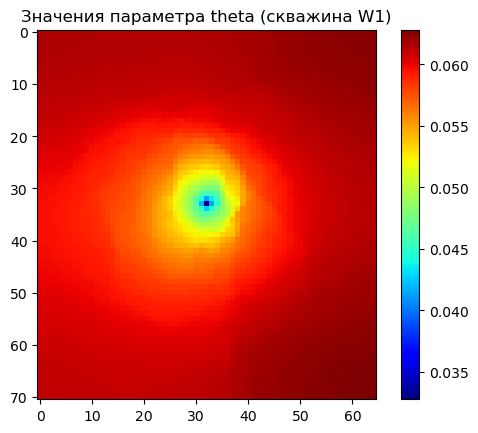


--- Обработка скважины W2 ---


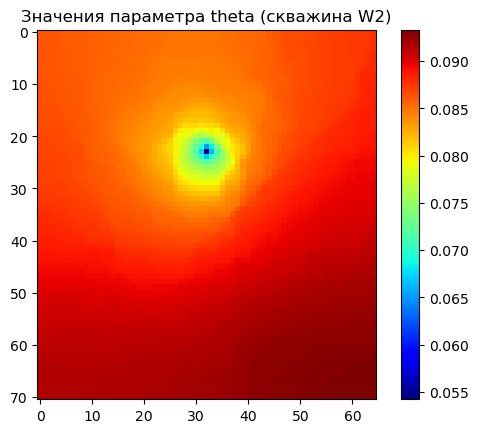


--- Обработка скважины W3 ---


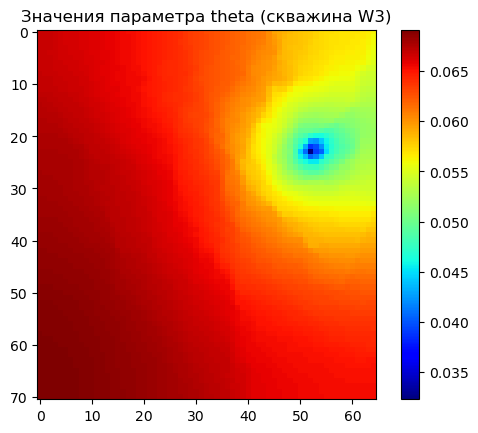


--- Обработка скважины W4 ---


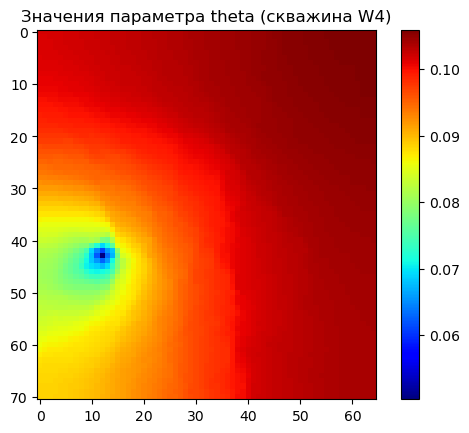


--- Обработка скважины W5 ---


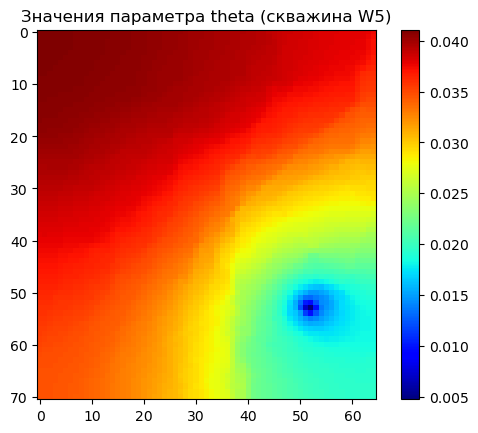


--- Обработка скважины W6 ---


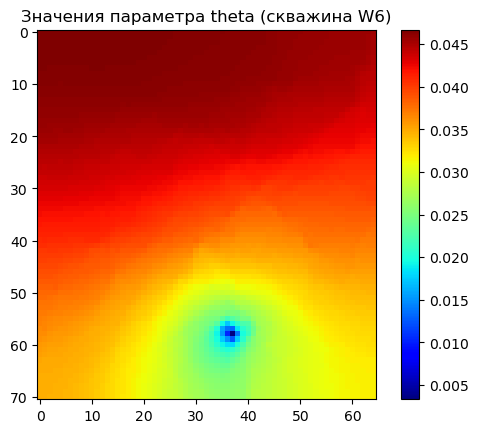


--- Обработка скважины W7 ---


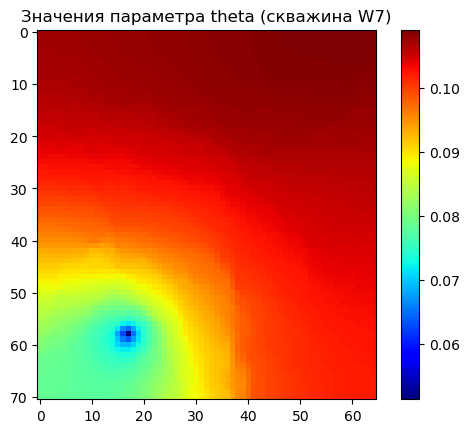


--- Обработка скважины W8 ---


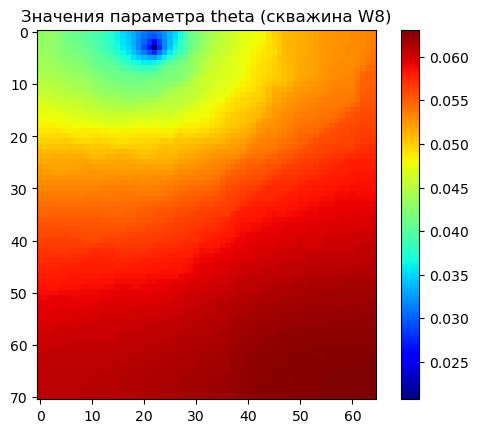


--- Обработка скважины W9 ---


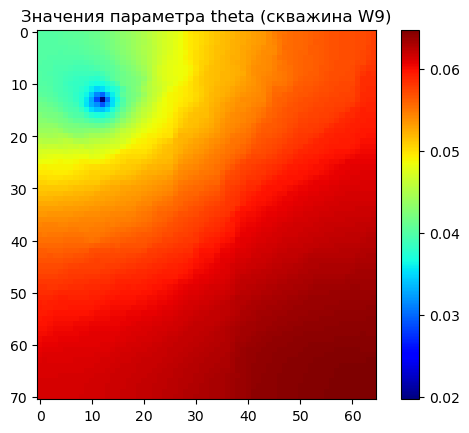


--- Обработка скважины W10 ---


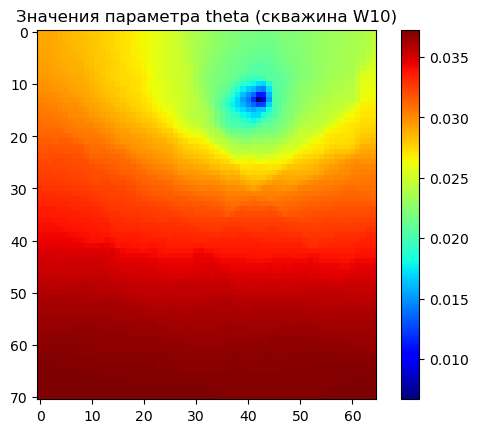


--- Обработка скважины W11 ---


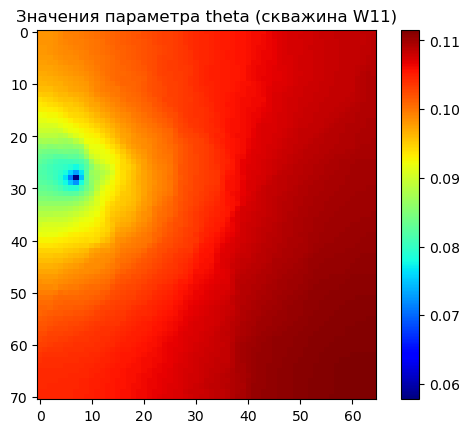


--- Обработка скважины W12 ---


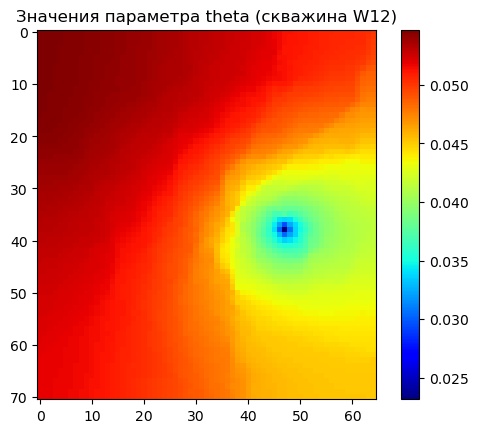

In [336]:
# Создаем правую часть системы (общая для всех скважин)
b = ct * dx * dx * heff * poro * a
B = b.reshape(-1, 1)

# Словарь для результатов
results = {}

# Цикл по всем скважинам
for w in wells:
    print(f"\n--- Обработка скважины {w['name']} ---")
    
    # Решаем систему
    A = build_system_matrix(
        perm = perm,
        heff = heff, 
        mu = mu,
        cDarcy = cDarcy,
        well_rc = w["rc"], 
        well_index=w["WI"],
        eps=1e-30
        )
    x = spsolve(A, B)
    
    # Преобразуем решение
    theta = np.reshape(x, (N, M))
    results[f'theta_{w["name"]}'] = theta

    
    display_grid(theta, f'Значения параметра theta (скважина {w["name"]})')

In [337]:
from collections import deque

def create_well_mask(N, M, well_i, well_j):
    well_mask = np.zeros((N, M), dtype=bool)
    well_mask[well_i, well_j] = True
    return well_mask

def neighbors4(i, j, N, M): 
    """
    Смотрим соседей, если в границах - возвращаем
    """
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]: 
        ni, nj = i + di, j + dj 
        if 0 <= ni < N and 0 <= nj < M: 
            yield ni, nj

def dilate_mask(mask, N, M, radius):
    """Создает расширенную маску вокруг принятых ячеек"""
    dilated = np.zeros_like(mask)
    for i in range(N):
        for j in range(M):
            if mask[i,j] > 0:
                # Создаем окно вокруг текущей ячейки
                i_start = max(0, i-radius)
                i_end = min(N, i+radius+1)
                j_start = max(0, j-radius)
                j_end = min(M, j+radius+1)
                
                # Проверяем условие |k| + |s| < radius+1 для каждой ячейки в окне
                for k in range(i_start, i_end):
                    for s in range(j_start, j_end):
                        if abs(k-i) + abs(s-j) < radius+1:
                            dilated[k,s] = 1
    return dilated

def calculate_threshold(theta_discret, theta_accepted, theta_dilation, heff, poro, dx):
    """Вычисляет пороговое значение для текущего шага"""
    # Создаем маску для необработанных ячеек в области дилатации
    mask = (theta_dilation == 1) & (theta_accepted == 0)
    
    # Вычисляем числитель и знаменатель порогового значения
    #тут на dx можно сократить
    numerator = np.sum(theta_discret[mask] * heff[mask] * poro[mask] * dx**2)
    denominator = np.sum(heff[mask] * poro[mask] * dx**2)
    
    return numerator / denominator if denominator > 0 else 0

def connected_components(mask):
    """
    Возвращает список 4-связных компонент для булевой маски.
    Каждая компонента — список пар (i, j).
    """
    N, M = mask.shape[0], mask.shape[1]
    visited = np.zeros_like(mask, dtype=bool)
    comps = []

    for i in range(N):
        for j in range(M):
            if mask[i, j] and not visited[i, j]:
                comp = []
                q = deque([(i, j)])
                visited[i, j] = True

                while q:
                    ci, cj = q.popleft()
                    comp.append((ci, cj))

                    for ni, nj in neighbors4(ci, cj, N, M):
                        if mask[ni, nj] and not visited[ni, nj]:
                            visited[ni, nj] = True
                            q.append((ni, nj))

                comps.append(comp)

    return comps


def process_step(theta_discret, theta_accepted, theta_dilation, threshold, heff, poro, dx):
    """
    Один шаг алгоритма:
    принимает ячейки внутри области dilation, у которых theta_discret < threshold,
    и присваивает им текущее пороговое значение.
    """
    mask = (
        (theta_dilation == 1) &
        (theta_accepted == 0) &
        (theta_discret < threshold)
    )

    theta_discret[mask] = threshold
    theta_accepted[mask] = 1

    return theta_discret, theta_accepted


def cleanup_newly_accepted(theta_discret, theta_accepted, theta_accepted_prev,
                           heff, poro, dx, well_mask,
                           min_cells=2, min_pv=0.0):
    """
    Удаляет нежелательные новые компоненты:
    - слишком маленькие по числу ячеек,
    - слишком маленькие по pore volume,
    - не имеющие контакта с предыдущим accepted-set.
    """
    def component_pv(comp):
        return sum(heff[i, j] * poro[i, j] * dx**2 for i, j in comp)

    def touches_old_accepted(comp):
        N, M = theta_accepted_prev.shape[0], theta_accepted_prev.shape[1]
        for i, j in comp:
            for ni, nj in neighbors4(i, j, N, M):
                if well_mask[ni, nj] or theta_accepted_prev[ni, nj] == 1:
                    return True
        return False

    new_cells = ((theta_accepted == 1) & (theta_accepted_prev == 0) & ~well_mask)
    comps = connected_components(new_cells)

    keep_mask = np.zeros_like(theta_accepted, dtype=bool)

    for comp in comps:
        size = len(comp)
        pv = component_pv(comp)
        touches = touches_old_accepted(comp)

        keep = touches and (size >= min_cells or pv >= min_pv)

        if keep:
            for i, j in comp:
                keep_mask[i, j] = True

    reject_mask = new_cells & (~keep_mask)
    theta_accepted[reject_mask] = 0

    return theta_discret, theta_accepted


def enforce_global_connectivity(theta_accepted, well_i, well_j):
    """
    Оставляет только те accepted-ячейки, которые достижимы от скважины
    по 4-связности. Остальные считаются disconnected.
    """
    N, M = theta_accepted.shape[0], theta_accepted.shape[1]

    visited = np.zeros_like(theta_accepted, dtype=bool)

    if theta_accepted[well_i, well_j] != 1:
        return theta_accepted, np.zeros_like(theta_accepted, dtype=bool)

    stack = [(well_i, well_j)]
    visited[well_i, well_j] = True

    while stack:
        i, j = stack.pop()

        for ni, nj in neighbors4(i, j, N, M):
            if theta_accepted[ni, nj] == 1 and not visited[ni, nj]:
                visited[ni, nj] = True
                stack.append((ni, nj))

    disconnected = (theta_accepted == 1) & (~visited)
    theta_accepted[disconnected] = 0

    return theta_accepted, disconnected

def remove_weak_cells(theta_accepted, well_i, well_j, min_neighbors=2):
    N, M = theta_accepted.shape[0], theta_accepted.shape[1]
    to_remove = []

    for i in range(N):
        for j in range(M):
            if theta_accepted[i, j] == 1:
                # well-cell никогда не удаляем
                if i == well_i and j == well_j:
                    continue

                neighbors = sum(
                    theta_accepted[ni, nj]
                    for ni, nj in neighbors4(i, j, N, M)
                )

                if neighbors < min_neighbors:
                    to_remove.append((i, j))

    removed_mask = np.zeros_like(theta_accepted, dtype=bool)
    for i, j in to_remove:
        theta_accepted[i, j] = 0
        removed_mask[i, j] = True

    return theta_accepted, removed_mask

def main_algorithm(theta, heff, poro, dx, well_i, well_j,
                   tolerance=0.005, radius=10,
                   min_cells=2, min_pv=0.0,
                   min_neighbors=1,
                   max_steps=300, stall_limit=5):
    N, M = poro.shape[0], poro.shape[1]
    theta_initial = theta.copy()
    theta_discret = theta.copy()

    theta_accepted = np.zeros((N, M), dtype=np.uint8)
    theta_accepted[well_i, well_j] = 1
    well_mask = create_well_mask(N, M, well_i, well_j)

    step = 0
    stall_counter = 0
    prev_accepted_count = np.sum(theta_accepted)

    while True:
        theta_dilation = dilate_mask(theta_accepted, N, M, radius=radius)

        threshold = calculate_threshold(
            theta_discret, theta_accepted, theta_dilation, heff, poro, dx
        )

        # если расширяться больше некуда
        if threshold == 0:
            print("\nStopped: threshold became zero (no candidates left).")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = np.max(theta_discret[theta_accepted == 1]) if np.any(theta_accepted == 1) else 0
            break

        theta_accepted_prev = theta_accepted.copy()

        theta_discret, theta_accepted = process_step(
            theta_discret, theta_accepted, theta_dilation, threshold, heff, poro, dx
        )

        theta_discret, theta_accepted = cleanup_newly_accepted(
            theta_discret=theta_discret,
            theta_accepted=theta_accepted,
            theta_accepted_prev=theta_accepted_prev,
            heff=heff,
            poro=poro,
            dx=dx,
            well_mask=well_mask,
            min_cells=min_cells,
            min_pv=min_pv
        )

        theta_accepted, disconnected_mask = enforce_global_connectivity(
            theta_accepted, well_i, well_j
        )
        theta_discret[disconnected_mask] = theta_initial[disconnected_mask]

        theta_accepted, weak_removed_mask = remove_weak_cells(
            theta_accepted,
            well_i=well_i,
            well_j=well_j,
            min_neighbors=min_neighbors
        )
        theta_discret[weak_removed_mask] = theta_initial[weak_removed_mask]

        # после удаления слабых ячеек ещё раз восстанавливаем глобальную связность
        theta_accepted, disconnected_mask_2 = enforce_global_connectivity(
            theta_accepted, well_i, well_j
        )
        theta_discret[disconnected_mask_2] = theta_initial[disconnected_mask_2]

        step += 1
        accepted_count = np.sum(theta_accepted)
        accepted_ratio = accepted_count / theta_accepted.size

        print(f"Step {step}, threshold: {threshold:.6f}, accepted cells: {accepted_ratio*100:.2f}%")

        if accepted_ratio >= (1.0 - tolerance):
            print(f"\nAlgorithm converged after {step} steps")
            print(f"Final acceptance ratio: {accepted_ratio*100:.2f}%")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        if accepted_count == prev_accepted_count:
            stall_counter += 1
        else:
            stall_counter = 0

        if stall_counter >= stall_limit:
            print(f"\nStopped: no progress for {stall_limit} iterations.")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        if step >= max_steps:
            print(f"\nStopped: reached max_steps={max_steps}")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break

        prev_accepted_count = accepted_count

    return theta_discret, theta_accepted, step, well_mask

def neighboring_labels(comp, labels):
    """
    Возвращает словарь:
    {label_value: число контактов по границе}
    """
    N, M = labels.shape[0], labels.shape[1]
    comp_set = set(comp)
    counts = {}

    for i, j in comp:
        for ni, nj in neighbors4(i, j, N, M):
            if (ni, nj) not in comp_set:
                lbl = labels[ni, nj]
                counts[lbl] = counts.get(lbl, 0) + 1

    return counts

def relabel_small_components(theta_discret, well_mask, min_cells=2):
    """
    Убирает мелкие 4-связные компоненты каждого интервала.
    Компоненты меньше min_cells переназначаются в соседний интервал.
    """
    labels = theta_discret.copy()
    unique_vals = np.unique(labels)

    changed = False

    for val in unique_vals:
        mask = (labels == val) & ~well_mask
        comps = connected_components(mask)

        for comp in comps:
            if len(comp) < min_cells:
                neighbor_counts = neighboring_labels(comp, labels)

                # убрать свой же label, если случайно попал
                neighbor_counts.pop(val, None)

                if len(neighbor_counts) == 0:
                    continue

                # выбрать соседа с максимальным числом контактов
                new_val = max(neighbor_counts.items(), key=lambda x: x[1])[0]

                for i, j in comp:
                    labels[i, j] = new_val

                changed = True

    return labels, changed

def final_interval_cleanup(theta_discret, well_mask, min_cells=4, max_iter=20):
    labels = theta_discret.copy()

    for it in range(max_iter):
        labels, changed = relabel_small_components(labels, well_mask, min_cells=min_cells)

        if not changed:
            print(f"Final cleanup converged after {it+1} iterations")
            return labels

    print("Warning: final cleanup reached max_iter")
    return labels

In [338]:
theta_discret_all = []

Step 1, threshold: 0.048724, accepted cells: 0.82%
Step 2, threshold: 0.052730, accepted cells: 2.73%
Step 3, threshold: 0.055269, accepted cells: 5.63%
Step 4, threshold: 0.057153, accepted cells: 10.12%
Step 5, threshold: 0.058344, accepted cells: 16.06%
Step 6, threshold: 0.059330, accepted cells: 23.97%
Step 7, threshold: 0.059991, accepted cells: 33.22%
Step 8, threshold: 0.060503, accepted cells: 42.58%
Step 9, threshold: 0.060925, accepted cells: 52.44%
Step 10, threshold: 0.061204, accepted cells: 62.32%
Step 11, threshold: 0.061418, accepted cells: 71.57%
Step 12, threshold: 0.061628, accepted cells: 79.96%
Step 13, threshold: 0.061850, accepted cells: 84.81%
Step 14, threshold: 0.062031, accepted cells: 88.17%
Step 15, threshold: 0.062201, accepted cells: 91.53%
Step 16, threshold: 0.062335, accepted cells: 94.08%
Step 17, threshold: 0.062453, accepted cells: 96.32%
Step 18, threshold: 0.062585, accepted cells: 98.11%
Step 19, threshold: 0.062678, accepted cells: 98.92%
Step 

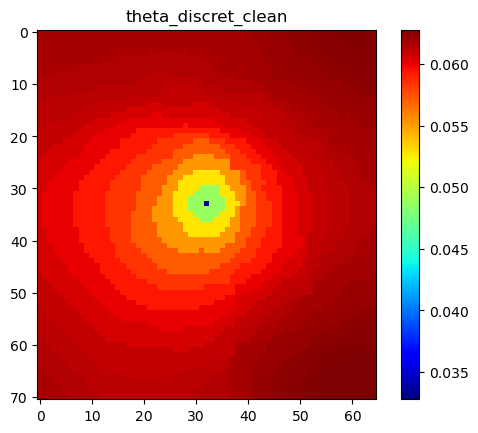

Step 1, threshold: 0.076102, accepted cells: 0.80%
Step 2, threshold: 0.081000, accepted cells: 2.90%
Step 3, threshold: 0.083217, accepted cells: 5.76%
Step 4, threshold: 0.084385, accepted cells: 9.99%
Step 5, threshold: 0.085167, accepted cells: 15.71%
Step 6, threshold: 0.085814, accepted cells: 22.43%
Step 7, threshold: 0.086410, accepted cells: 29.47%
Step 8, threshold: 0.086967, accepted cells: 36.88%
Step 9, threshold: 0.087525, accepted cells: 43.90%
Step 10, threshold: 0.088201, accepted cells: 49.97%
Step 11, threshold: 0.088832, accepted cells: 55.04%
Step 12, threshold: 0.089413, accepted cells: 59.52%
Step 13, threshold: 0.089908, accepted cells: 63.94%
Step 14, threshold: 0.090404, accepted cells: 68.30%
Step 15, threshold: 0.090891, accepted cells: 72.74%
Step 16, threshold: 0.091274, accepted cells: 77.25%
Step 17, threshold: 0.091703, accepted cells: 83.34%
Step 18, threshold: 0.091984, accepted cells: 88.02%
Step 19, threshold: 0.092208, accepted cells: 90.34%
Step 2

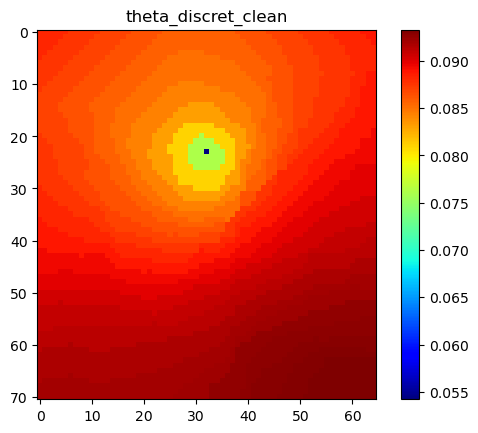

Step 1, threshold: 0.047724, accepted cells: 0.78%
Step 2, threshold: 0.051295, accepted cells: 2.62%
Step 3, threshold: 0.053984, accepted cells: 5.98%
Step 4, threshold: 0.055774, accepted cells: 9.69%
Step 5, threshold: 0.057451, accepted cells: 14.11%
Step 6, threshold: 0.059040, accepted cells: 18.59%
Step 7, threshold: 0.060338, accepted cells: 22.23%
Step 8, threshold: 0.061533, accepted cells: 26.18%
Step 9, threshold: 0.062634, accepted cells: 30.83%
Step 10, threshold: 0.063416, accepted cells: 35.06%
Step 11, threshold: 0.064113, accepted cells: 39.91%
Step 12, threshold: 0.064778, accepted cells: 45.27%
Step 13, threshold: 0.065352, accepted cells: 51.12%
Step 14, threshold: 0.065696, accepted cells: 56.64%
Step 15, threshold: 0.066083, accepted cells: 61.52%
Step 16, threshold: 0.066498, accepted cells: 66.22%
Step 17, threshold: 0.066861, accepted cells: 71.22%
Step 18, threshold: 0.067132, accepted cells: 75.17%
Step 19, threshold: 0.067416, accepted cells: 78.68%
Step 2

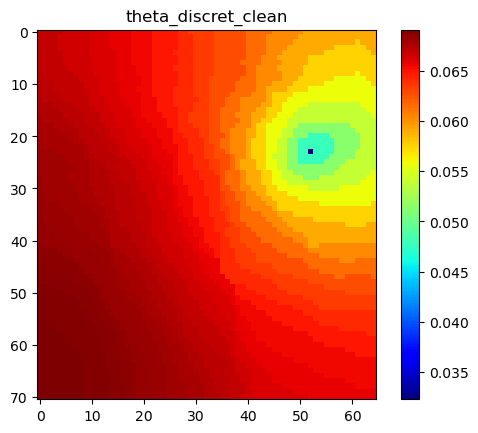

Step 1, threshold: 0.074579, accepted cells: 0.80%
Step 2, threshold: 0.083110, accepted cells: 3.14%
Step 3, threshold: 0.086391, accepted cells: 6.37%
Step 4, threshold: 0.088804, accepted cells: 10.18%
Step 5, threshold: 0.091396, accepted cells: 14.91%
Step 6, threshold: 0.093316, accepted cells: 19.59%
Step 7, threshold: 0.094871, accepted cells: 23.40%
Step 8, threshold: 0.096189, accepted cells: 27.37%
Step 9, threshold: 0.097528, accepted cells: 31.66%
Step 10, threshold: 0.098827, accepted cells: 36.40%
Step 11, threshold: 0.100094, accepted cells: 41.21%
Step 12, threshold: 0.101295, accepted cells: 46.52%
Step 13, threshold: 0.102191, accepted cells: 53.39%
Step 14, threshold: 0.102738, accepted cells: 58.98%
Step 15, threshold: 0.103176, accepted cells: 64.23%
Step 16, threshold: 0.103569, accepted cells: 68.97%
Step 17, threshold: 0.103909, accepted cells: 74.06%
Step 18, threshold: 0.104139, accepted cells: 79.22%
Step 19, threshold: 0.104351, accepted cells: 82.80%
Step 

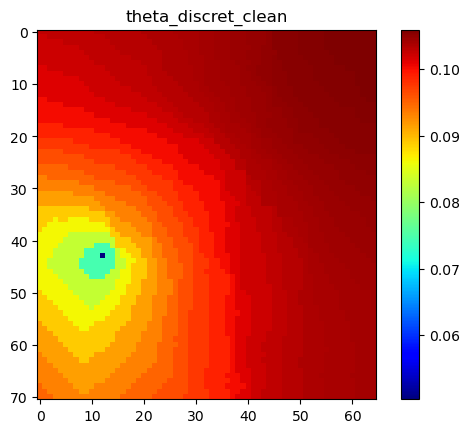

Step 1, threshold: 0.014911, accepted cells: 0.59%
Step 2, threshold: 0.018285, accepted cells: 2.58%
Step 3, threshold: 0.019878, accepted cells: 5.79%
Step 4, threshold: 0.021076, accepted cells: 9.36%
Step 5, threshold: 0.022477, accepted cells: 12.63%
Step 6, threshold: 0.024734, accepted cells: 15.75%
Step 7, threshold: 0.026760, accepted cells: 18.89%
Step 8, threshold: 0.028235, accepted cells: 22.38%
Step 9, threshold: 0.029516, accepted cells: 26.26%
Step 10, threshold: 0.030795, accepted cells: 30.34%
Step 11, threshold: 0.032157, accepted cells: 34.91%
Step 12, threshold: 0.033355, accepted cells: 39.67%
Step 13, threshold: 0.034383, accepted cells: 45.63%
Step 14, threshold: 0.035295, accepted cells: 51.22%
Step 15, threshold: 0.036050, accepted cells: 56.49%
Step 16, threshold: 0.036778, accepted cells: 61.39%
Step 17, threshold: 0.037604, accepted cells: 66.89%
Step 18, threshold: 0.038191, accepted cells: 72.18%
Step 19, threshold: 0.038663, accepted cells: 76.45%
Step 2

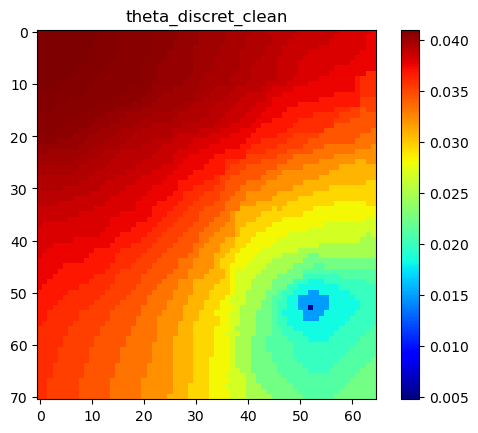

Step 1, threshold: 0.022143, accepted cells: 0.82%
Step 2, threshold: 0.026425, accepted cells: 3.36%
Step 3, threshold: 0.028387, accepted cells: 6.67%
Step 4, threshold: 0.029929, accepted cells: 10.27%
Step 5, threshold: 0.031261, accepted cells: 14.32%
Step 6, threshold: 0.032514, accepted cells: 19.07%
Step 7, threshold: 0.033696, accepted cells: 23.99%
Step 8, threshold: 0.034887, accepted cells: 29.06%
Step 9, threshold: 0.036111, accepted cells: 34.63%
Step 10, threshold: 0.037397, accepted cells: 39.54%
Step 11, threshold: 0.038536, accepted cells: 44.20%
Step 12, threshold: 0.039537, accepted cells: 48.34%
Step 13, threshold: 0.040602, accepted cells: 52.83%
Step 14, threshold: 0.041588, accepted cells: 57.25%
Step 15, threshold: 0.042518, accepted cells: 61.52%
Step 16, threshold: 0.043394, accepted cells: 66.02%
Step 17, threshold: 0.044101, accepted cells: 70.12%
Step 18, threshold: 0.044807, accepted cells: 74.89%
Step 19, threshold: 0.045408, accepted cells: 79.52%
Step 

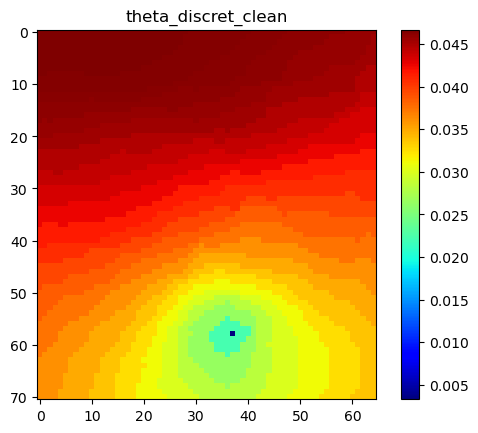

Step 1, threshold: 0.074412, accepted cells: 0.87%
Step 2, threshold: 0.078441, accepted cells: 3.25%
Step 3, threshold: 0.081833, accepted cells: 6.89%
Step 4, threshold: 0.084749, accepted cells: 10.23%
Step 5, threshold: 0.088112, accepted cells: 13.24%
Step 6, threshold: 0.090931, accepted cells: 16.19%
Step 7, threshold: 0.093327, accepted cells: 19.50%
Step 8, threshold: 0.096203, accepted cells: 23.25%
Step 9, threshold: 0.098319, accepted cells: 27.00%
Step 10, threshold: 0.099932, accepted cells: 31.12%
Step 11, threshold: 0.101021, accepted cells: 35.84%
Step 12, threshold: 0.101944, accepted cells: 41.11%
Step 13, threshold: 0.102688, accepted cells: 46.59%
Step 14, threshold: 0.103318, accepted cells: 51.46%
Step 15, threshold: 0.104152, accepted cells: 56.27%
Step 16, threshold: 0.104909, accepted cells: 60.80%
Step 17, threshold: 0.105566, accepted cells: 65.27%
Step 18, threshold: 0.106418, accepted cells: 70.36%
Step 19, threshold: 0.107105, accepted cells: 75.41%
Step 

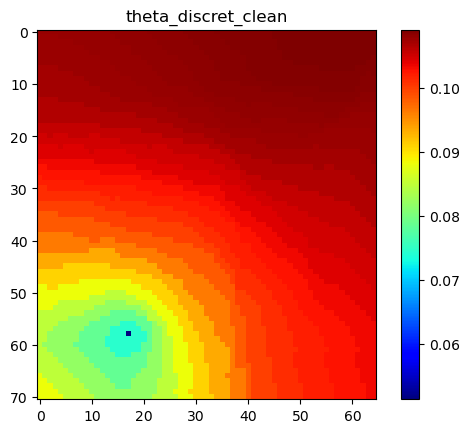

Step 1, threshold: 0.034341, accepted cells: 0.87%
Step 2, threshold: 0.040422, accepted cells: 2.64%
Step 3, threshold: 0.042292, accepted cells: 4.92%
Step 4, threshold: 0.044118, accepted cells: 7.84%
Step 5, threshold: 0.045805, accepted cells: 10.79%
Step 6, threshold: 0.047356, accepted cells: 13.82%
Step 7, threshold: 0.048865, accepted cells: 17.12%
Step 8, threshold: 0.050235, accepted cells: 20.43%
Step 9, threshold: 0.051610, accepted cells: 24.64%
Step 10, threshold: 0.052631, accepted cells: 29.01%
Step 11, threshold: 0.053530, accepted cells: 33.72%
Step 12, threshold: 0.054525, accepted cells: 38.24%
Step 13, threshold: 0.055553, accepted cells: 42.62%
Step 14, threshold: 0.056455, accepted cells: 47.11%
Step 15, threshold: 0.057394, accepted cells: 51.35%
Step 16, threshold: 0.058152, accepted cells: 55.45%
Step 17, threshold: 0.058843, accepted cells: 59.85%
Step 18, threshold: 0.059407, accepted cells: 64.03%
Step 19, threshold: 0.059910, accepted cells: 68.15%
Step 2

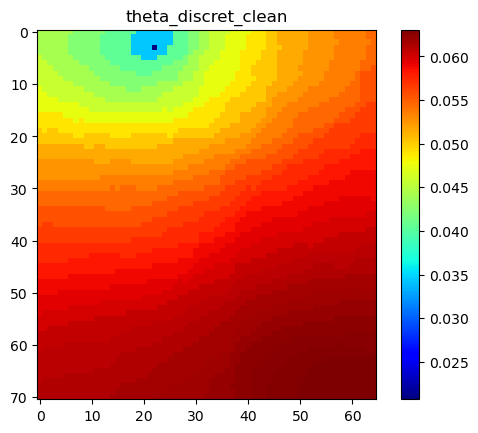

Step 1, threshold: 0.037344, accepted cells: 0.80%
Step 2, threshold: 0.041151, accepted cells: 3.16%
Step 3, threshold: 0.043294, accepted cells: 6.83%
Step 4, threshold: 0.046175, accepted cells: 10.05%
Step 5, threshold: 0.048485, accepted cells: 13.04%
Step 6, threshold: 0.049947, accepted cells: 15.71%
Step 7, threshold: 0.051384, accepted cells: 18.79%
Step 8, threshold: 0.052238, accepted cells: 21.52%
Step 9, threshold: 0.053450, accepted cells: 25.37%
Step 10, threshold: 0.054330, accepted cells: 28.75%
Step 11, threshold: 0.055299, accepted cells: 32.44%
Step 12, threshold: 0.056356, accepted cells: 37.05%
Step 13, threshold: 0.057179, accepted cells: 41.97%
Step 14, threshold: 0.057901, accepted cells: 46.96%
Step 15, threshold: 0.058797, accepted cells: 51.35%
Step 16, threshold: 0.059576, accepted cells: 56.08%
Step 17, threshold: 0.060289, accepted cells: 60.65%
Step 18, threshold: 0.060823, accepted cells: 65.07%
Step 19, threshold: 0.061251, accepted cells: 69.77%
Step 

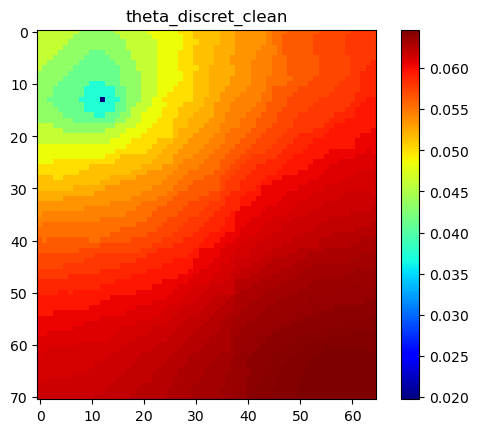

Step 1, threshold: 0.017889, accepted cells: 0.85%
Step 2, threshold: 0.020944, accepted cells: 2.62%
Step 3, threshold: 0.022421, accepted cells: 6.18%
Step 4, threshold: 0.023854, accepted cells: 10.51%
Step 5, threshold: 0.024899, accepted cells: 14.91%
Step 6, threshold: 0.026074, accepted cells: 18.72%
Step 7, threshold: 0.027423, accepted cells: 23.36%
Step 8, threshold: 0.028586, accepted cells: 27.91%
Step 9, threshold: 0.029585, accepted cells: 33.04%
Step 10, threshold: 0.030632, accepted cells: 38.55%
Step 11, threshold: 0.031430, accepted cells: 42.88%
Step 12, threshold: 0.032203, accepted cells: 47.45%
Step 13, threshold: 0.032795, accepted cells: 51.57%
Step 14, threshold: 0.033406, accepted cells: 55.71%
Step 15, threshold: 0.034068, accepted cells: 60.02%
Step 16, threshold: 0.034719, accepted cells: 64.33%
Step 17, threshold: 0.035330, accepted cells: 68.84%
Step 18, threshold: 0.035800, accepted cells: 73.13%
Step 19, threshold: 0.036204, accepted cells: 77.38%
Step 

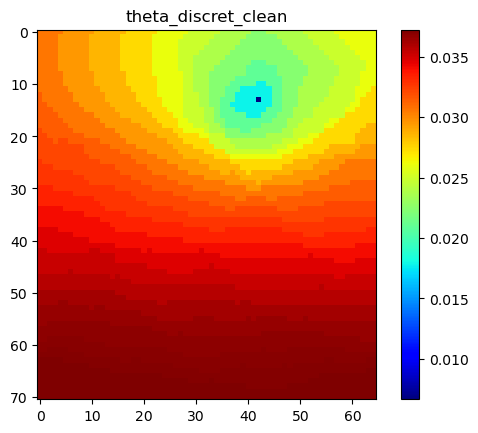

Step 1, threshold: 0.083662, accepted cells: 1.11%
Step 2, threshold: 0.089174, accepted cells: 3.38%
Step 3, threshold: 0.092441, accepted cells: 5.76%
Step 4, threshold: 0.094825, accepted cells: 8.52%
Step 5, threshold: 0.097060, accepted cells: 11.81%
Step 6, threshold: 0.098765, accepted cells: 16.08%
Step 7, threshold: 0.100148, accepted cells: 20.69%
Step 8, threshold: 0.101329, accepted cells: 24.92%
Step 9, threshold: 0.102472, accepted cells: 29.49%
Step 10, threshold: 0.103396, accepted cells: 34.41%
Step 11, threshold: 0.104266, accepted cells: 39.98%
Step 12, threshold: 0.105222, accepted cells: 46.20%
Step 13, threshold: 0.105984, accepted cells: 51.68%
Step 14, threshold: 0.106775, accepted cells: 56.64%
Step 15, threshold: 0.107451, accepted cells: 61.45%
Step 16, threshold: 0.108084, accepted cells: 67.04%
Step 17, threshold: 0.108592, accepted cells: 72.37%
Step 18, threshold: 0.109120, accepted cells: 77.53%
Step 19, threshold: 0.109566, accepted cells: 81.86%
Step 2

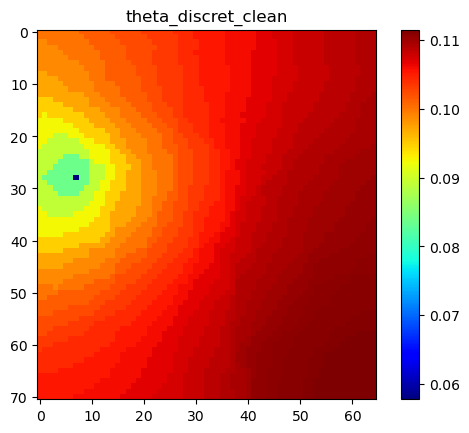

Step 1, threshold: 0.036079, accepted cells: 0.74%
Step 2, threshold: 0.039204, accepted cells: 2.60%
Step 3, threshold: 0.041093, accepted cells: 5.98%
Step 4, threshold: 0.042712, accepted cells: 11.05%
Step 5, threshold: 0.044202, accepted cells: 16.23%
Step 6, threshold: 0.045454, accepted cells: 21.41%
Step 7, threshold: 0.046313, accepted cells: 26.93%
Step 8, threshold: 0.047208, accepted cells: 32.24%
Step 9, threshold: 0.048281, accepted cells: 37.36%
Step 10, threshold: 0.049194, accepted cells: 42.47%
Step 11, threshold: 0.050042, accepted cells: 48.54%
Step 12, threshold: 0.050807, accepted cells: 55.28%
Step 13, threshold: 0.051380, accepted cells: 61.50%
Step 14, threshold: 0.051912, accepted cells: 67.26%
Step 15, threshold: 0.052292, accepted cells: 73.04%
Step 16, threshold: 0.052626, accepted cells: 77.12%
Step 17, threshold: 0.052898, accepted cells: 80.56%
Step 18, threshold: 0.053183, accepted cells: 83.81%
Step 19, threshold: 0.053424, accepted cells: 86.20%
Step 

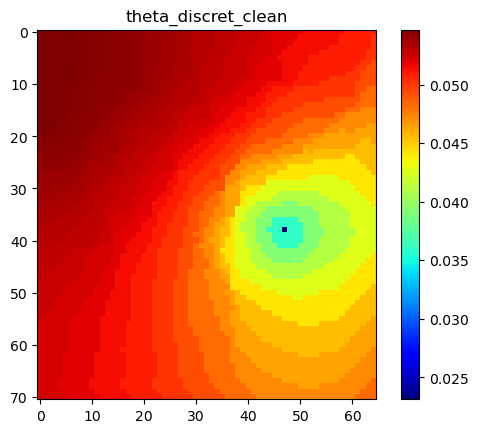

In [339]:
for i,well in enumerate(wells):
    theta_discret, theta_accepted, total_steps, well_mask = main_algorithm(
        theta=results[f'theta_W{i+1}'],
        heff=heff,
        poro=poro,
        dx=dx,
        well_i=well['rc'][0],
        well_j=well['rc'][1],
        radius=6,
        tolerance=0.005,
        min_cells=4,
        min_pv=0.0,
        min_neighbors=1,
        max_steps=300,
        stall_limit=5
    )

    theta_discret_clean = final_interval_cleanup(theta_discret, well_mask=well_mask, min_cells=4, max_iter=30)
    display_grid(theta_discret_clean, "theta_discret_clean")
    theta_discret_all.append(theta_discret_clean)

## Вычисление T

In [340]:
def build_mesh_and_pairs(theta_discret):
    """Группируем ячейки пласта по PSS-интервалам"""
    """Создание mesh и pairs_list по карте после апскейлинга"""
    valid_mask = ~np.isnan(theta_discret)
    mesh = np.unique(theta_discret[valid_mask])
    mesh.sort()
    theta_mesh = np.array(mesh)
    
    mask_interval = np.zeros((theta_discret.shape[0], theta_discret.shape[1], len(theta_mesh)))
    for i in range(len(theta_mesh)):
        mask_interval[..., i] = theta_discret == theta_mesh[i]
    
    pairs_list = []
    for k in range(len(theta_mesh)):
        interval_indxs_2D = np.where(mask_interval[..., k] == 1)
        pairs_list_unique = list(zip(interval_indxs_2D[0], interval_indxs_2D[1]))
        pairs_list.append(pairs_list_unique)
    
    return theta_mesh, pairs_list

In [341]:
def calculate_T(theta_discret, heff, perm, poro, well_rc, well_index):
    theta_mesh, pairs_list = build_mesh_and_pairs(theta_discret)
    pressure_new = np.zeros_like(theta_discret)
    for interval_number in range(1, len(theta_mesh)):
        size_system = len(pairs_list[interval_number])
        Matrix = np.zeros((size_system, size_system))
        pairs = pairs_list[interval_number]
        for indx in range(size_system):
            two_d = pairs[indx]
            i, j = two_d
            coeffs = np.zeros(4)
            if i>0:
                left_idx = (i-1, j)
                if theta_discret[left_idx] == theta_discret[two_d]:
                    coeffs[0] = cDarcy * (heff[left_idx] + heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(left_idx)
                    Matrix[indx][l_column] = - coeffs[0]
                elif theta_discret[left_idx] < theta_discret[two_d]:
                    coeffs[0] = 2 * cDarcy * (heff[left_idx] + heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
            if i<np.shape(theta_discret)[0]-1:
                right_idx = (i+1, j)
                if theta_discret[right_idx] == theta_discret[two_d]:
                    coeffs[1] = cDarcy * (heff[right_idx] + heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(right_idx)
                    Matrix[indx][l_column] = - coeffs[1]
                elif theta_discret[right_idx] < theta_discret[two_d]:
                    coeffs[1] = 2 * cDarcy * (heff[right_idx] + heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
            if j>0:
                top_idx = (i, j-1)
                if theta_discret[top_idx] == theta_discret[two_d]:
                    coeffs[2] = cDarcy * (heff[top_idx] + heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(top_idx)
                    Matrix[indx][l_column] = - coeffs[2]
                elif theta_discret[top_idx] < theta_discret[two_d]:
                    coeffs[2] = 2 * cDarcy * (heff[top_idx] + heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
            if j<np.shape(theta_discret)[1]-1:
                bot_idx = (i, j+1)
                if theta_discret[bot_idx] == theta_discret[two_d]:
                    coeffs[3] = cDarcy * (heff[bot_idx] + heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(bot_idx)
                    Matrix[indx][l_column] = - coeffs[3]
                elif theta_discret[bot_idx] < theta_discret[two_d]:
                    coeffs[3] = 2 * cDarcy * (heff[bot_idx] + heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
            Matrix[indx][indx] = np.sum(coeffs)
            if np.sum(coeffs) == 0:
                print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
                print('Эфф. толщина в ячейках с нулевой строкой')
                print(heff[two_d], heff[left_idx], heff[right_idx], heff[top_idx], heff[left_idx])
                print('Проницаемость в ячейках с нулевой строкой')
                print(perm[two_d], perm[left_idx], perm[right_idx], perm[top_idx], perm[left_idx])
        b = np.zeros(size_system)
        for indx in range(size_system):
            two_d = pairs[indx]
            b[indx] = heff[two_d] * poro[two_d] * dx * dx 
    
        x = solve(Matrix, b)
        #print(np.mean(x))
        
        for indx in range(size_system):
            two_d = pairs[indx]
            pressure_new[two_d] = x[indx]
    pressure_new[well_rc] = heff[well_rc] * poro[well_rc] * dx * dx / well_index
    delta_Vp = np.zeros(len(theta_mesh))

    for interval_number in range(0, len(theta_mesh)):
        size_system = len(pairs_list[interval_number])
        pairs = pairs_list[interval_number]
        for indx in range(size_system):
            two_d = pairs[indx]
            #i, j = two_d
            delta_Vp[interval_number] += heff[two_d] * poro[two_d] * dx * dx 

    numerator = np.zeros(len(theta_mesh)) # числитель дроби
    denominator = np.zeros_like(numerator) # знаменатель дроби
    Delta_PSS = np.zeros_like(numerator)

    for interval_number in range(0, len(theta_mesh)):
        size_system = len(pairs_list[interval_number])
        pairs = pairs_list[interval_number]

        for indx in range(size_system):
            two_d = pairs[indx]
            i, j = two_d
            coeffs = np.zeros(4)
            if i>0:
                left_idx = (i-1, j)
                if theta_discret[left_idx] > theta_discret[two_d]:
                    coeffs[0] = cDarcy * (heff[left_idx] + heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
            elif i == 0:
                coeffs[0] = cDarcy * heff[two_d] * perm[two_d]


            if i<np.shape(poro)[0]-1:
                right_idx = (i+1, j)
                if theta_discret[right_idx] > theta_discret[two_d]:
                    coeffs[1] = cDarcy * (heff[right_idx] + heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
            elif i == np.shape(poro)[0]-1:
                coeffs[1] = cDarcy * heff[two_d] * perm[two_d]

            if j>0:
                top_idx = (i, j-1)
                if theta_discret[top_idx] > theta_discret[two_d]:
                    coeffs[2] = cDarcy * (heff[top_idx] + heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
            elif j == 0:
                coeffs[2] = cDarcy * heff[two_d] * perm[two_d]


            if j<np.shape(poro)[1]-1:
                bot_idx = (i, j+1)
                if theta_discret[bot_idx] > theta_discret[two_d]:
                    coeffs[3] = cDarcy * (heff[bot_idx] + heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
            elif j == np.shape(poro)[1]-1:
                coeffs[3] = cDarcy * heff[two_d] * perm[two_d]
            T_sum = 0
            T_sum = np.sum(coeffs)
            numerator[interval_number] += T_sum * pressure_new[two_d]
            denominator[interval_number] += T_sum

        Delta_PSS[interval_number] = numerator[interval_number] / denominator[interval_number]
        # Delta_PSS[0] = pressure_new[well_rc] 
    if Delta_PSS[0] == 0:
        raise ValueError(
            f"Delta_PSS[0] == 0. "
            f"pairs_list[0]={pairs_list[0]}, "
            f"well_rc={well_rc}, "
            f"pressure_new[pairs_list[0][0]]={pressure_new[pairs_list[0][0]]}, "
            f"pressure_new[well_rc]={pressure_new[well_rc]}"
        )

    T_minus = delta_Vp / Delta_PSS


    pressure_new_plus = np.zeros_like(poro)
    pressure_new_plus.fill(np.nan)

    for interval_number in range(0, len(theta_mesh)):
        size_system = len(pairs_list[interval_number])
        Matrix = np.zeros((size_system, size_system))
        pairs = pairs_list[interval_number]
        for indx in range(size_system):
            two_d = pairs[indx]
            i, j = two_d
            coeffs = np.zeros(4)
            if i>0:
                left_idx = (i-1, j)
                if theta_discret[left_idx] == theta_discret[two_d]:
                    coeffs[0] = cDarcy * (heff[left_idx] + heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(left_idx)
                    Matrix[indx][l_column] = - coeffs[0]
                elif theta_discret[left_idx] > theta_discret[two_d]:
                    coeffs[0] = 2 * cDarcy * (heff[left_idx] + heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
            elif i == 0:
                coeffs[0] = 2 * cDarcy * (heff[two_d] + heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d]))

            if i<np.shape(poro)[0]-1:
                right_idx = (i+1, j)
                if theta_discret[right_idx] == theta_discret[two_d]:
                    coeffs[1] = cDarcy * (heff[right_idx] + heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(right_idx)
                    Matrix[indx][l_column] = - coeffs[1]
                elif theta_discret[right_idx] > theta_discret[two_d]:
                    coeffs[1] = 2 * cDarcy * (heff[right_idx] + heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))

            elif i == np.shape(poro)[0]-1:
                coeffs[1] = 2 * cDarcy * (heff[two_d] + heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d]))


            if j>0:
                top_idx = (i, j-1)
                if theta_discret[top_idx] == theta_discret[two_d]:
                    coeffs[2] = cDarcy * (heff[top_idx] + heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(top_idx)
                    Matrix[indx][l_column] = - coeffs[2]
                elif theta_discret[top_idx] > theta_discret[two_d]:
                    coeffs[2] = 2 * cDarcy * (heff[top_idx] + heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
            elif j == 0:
               coeffs[2] = 2 * cDarcy * (heff[two_d] + heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d])) 

            if j<np.shape(poro)[1]-1:
                bot_idx = (i, j+1)
                if theta_discret[bot_idx] == theta_discret[two_d]:
                    coeffs[3] = cDarcy * (heff[bot_idx] + heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
                    l_column = pairs.index(bot_idx)
                    Matrix[indx][l_column] = - coeffs[3]
                elif theta_discret[bot_idx] > theta_discret[two_d]:
                    coeffs[3] = 2 * cDarcy * (heff[bot_idx] + heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
            elif j == np.shape(poro)[1]-1:
                coeffs[3] = 2 * cDarcy * (heff[two_d] + heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d]))



            Matrix[indx][indx] = np.sum(coeffs)
            if np.sum(coeffs) == 0:
                print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
                print('Эфф. толщина в ячейках с нулевой строкой')
                print(heff[two_d], heff[left_idx], heff[right_idx], heff[top_idx], heff[left_idx])
                print('Проницаемость в ячейках с нулевой строкой')
                print(perm[two_d], perm[left_idx], perm[right_idx], perm[top_idx], perm[left_idx])
        b = np.zeros(size_system)
        for indx in range(size_system):
            two_d = pairs[indx]
            b[indx] = heff[two_d] * poro[two_d] * dx * dx 

        x = solve(Matrix, b)
        #print(np.mean(x))

        for indx in range(size_system):
            two_d = pairs[indx]
            pressure_new_plus[two_d] = x[indx]

    numerator = np.zeros(len(theta_mesh)) # числитель дроби
    denominator = np.zeros_like(numerator) # знаменатель дроби
    Delta_PSS_plus = np.zeros_like(numerator)

    for interval_number in range(1, len(theta_mesh)):
        size_system = len(pairs_list[interval_number])
        pairs = pairs_list[interval_number]

        for indx in range(size_system):
            two_d = pairs[indx]
            i, j = two_d
            coeffs = np.zeros(4)
            if i>0:
                left_idx = (i-1, j)
                if theta_discret[left_idx] < theta_discret[two_d]:
                    coeffs[0] = cDarcy * (heff[left_idx] + heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
            elif i == 0:
                coeffs[0] = cDarcy * heff[two_d] * perm[two_d]


            if i<np.shape(poro)[0]-1:
                right_idx = (i+1, j)
                if theta_discret[right_idx] < theta_discret[two_d]:
                    coeffs[1] = cDarcy * (heff[right_idx] + heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
            elif i == np.shape(poro)[0]-1:
                coeffs[1] = cDarcy * heff[two_d] * perm[two_d]

            if j>0:
                top_idx = (i, j-1)
                if theta_discret[top_idx] < theta_discret[two_d]:
                    coeffs[2] = cDarcy * (heff[top_idx] + heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
            elif j == 0:
                coeffs[2] = cDarcy * heff[two_d] * perm[two_d]


            if j<np.shape(poro)[1]-1:
                bot_idx = (i, j+1)
                if theta_discret[bot_idx] < theta_discret[two_d]:
                    coeffs[3] = cDarcy * (heff[bot_idx] + heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
            elif j == np.shape(poro)[1]-1:
                coeffs[3] = cDarcy * heff[two_d] * perm[two_d]

            T_sum = 0
            T_sum = np.sum(coeffs)
            numerator[interval_number] += T_sum * pressure_new_plus[two_d]
            denominator[interval_number] += T_sum

        Delta_PSS_plus[interval_number] = numerator[interval_number] / denominator[interval_number]
    Delta_PSS_plus[0] = pressure_new_plus[well_rc] # в случае если перф ячеек будет больше, нужно будет взвешивать на проводимость внутрь (по сути WI_cell)
    T_plus = delta_Vp / Delta_PSS_plus 
    
    return delta_Vp, T_minus, T_plus

In [342]:
theta_discret = theta_discret_all.copy()

In [343]:
T_minus = []
T_plus = []
delta_Vp = []

for i,well in enumerate(wells):
    print(f'Итерация {i}:')
    delta_Vp_i, T_minus_i, T_plus_i = calculate_T(theta_discret[i], heff, perm, poro, well['rc'] , well['WI'])
    delta_Vp.append(delta_Vp_i)
    T_minus.append(T_minus_i)
    T_plus.append(T_plus_i)

Итерация 0:
Итерация 1:
Итерация 2:
Итерация 3:
Итерация 4:
Итерация 5:
Итерация 6:
Итерация 7:
Итерация 8:
Итерация 9:
Итерация 10:
Итерация 11:


In [344]:
def peaceman_tau_for_vertical_well(
    well_rc,
    poro,
    permx,
    dx,
    mu,
    ct,
    cDarcy
):
    """
    DTOF на Peaceman radius для вертикальной скважины в одной grid-cell.

    well_rc : tuple/list
        Индекс скважины как (row, col), например [5, 15].
    poro : ndarray
        Пористость.
    permx : ndarray
        Проницаемость по x или изотропная проницаемость.
    permy : ndarray or None
        Проницаемость по y. Если None, считаем permy = permx.
    dx, dy : float
        Размеры ячейки. Если dy=None, считаем dy=dx.
    mu : float
        Вязкость.
    ct : float
        Полная сжимаемость.
    cDarcy : float
        Конверсионный коэффициент Darcy/transmissibility.
        Должен быть согласован с единицами perm, dx, mu, ct.
    """
    EULER_GAMMA = 0.5772156649015329

    i, j = well_rc

    phi_w = float(poro[i, j])
    kx_w = float(permx[i, j])
    ky_w = float(permx[i, j])
    dy = dx
    if phi_w <= 0 or kx_w <= 0 or ky_w <= 0:
        raise ValueError("В well-cell phi, kx, ky должны быть положительными")

    # однофазный случай: lambda_rt0 = 1 / mu
    lambda_rt0 = 1.0 / mu

    alpha_x = cDarcy * kx_w * lambda_rt0 / (phi_w * ct)
    alpha_y = cDarcy * ky_w * lambda_rt0 / (phi_w * ct)

    tau_p = 0.25 * math.exp(-EULER_GAMMA) * math.sqrt(
        dx**2 / alpha_x + dy**2 / alpha_y
    )

    return tau_p
#, alpha_x, alpha_y

In [345]:
tau_p_all = []

for well in wells:
    tau_p = peaceman_tau_for_vertical_well(
        well['rc'],
        poro,
        perm,
        dx,
        mu,
        ct,
        cDarcy
    )
    print(f"Peaceman tau for well at {well['rc']}: {tau_p}")
    tau_p_all.append(tau_p)

Peaceman tau for well at (33, 32): 0.4385762813025427
Peaceman tau for well at (23, 32): 0.4385762813025427
Peaceman tau for well at (23, 52): 0.4385762813025427
Peaceman tau for well at (43, 12): 0.4385762813025428
Peaceman tau for well at (53, 52): 0.4385762813025427
Peaceman tau for well at (58, 37): 0.4385762813025427
Peaceman tau for well at (58, 17): 0.4385762813025427
Peaceman tau for well at (3, 22): 0.4385762813025427
Peaceman tau for well at (13, 12): 0.4385762813025427
Peaceman tau for well at (13, 42): 0.4385762813025428
Peaceman tau for well at (28, 7): 0.4385762813025427
Peaceman tau for well at (38, 47): 0.4385762813025427


In [346]:
def calc_delta_Vp(tau_map, Vp):
    tau_unique = np.sort(np.unique(tau_map))    
    delta_Vp = np.zeros(len(tau_unique))
    for i, tau_val in enumerate(tau_unique):
        mask = (tau_map == tau_val)
        delta_Vp[i] = np.sum(Vp[mask])
    return delta_Vp

In [347]:
# Новая версия
def theta_to_tau_map(theta_discret, delta_Vp, ct, T_plus, T_minus, lambda_rt0, tau_p):
    """
    Строит карту 𝜏-интервалов из карты  θ-интервалов

    Parameters
    ----------
    theta_discret : np.ma.MaskedArray или np.ndarray
        2D/3D массив 𝜏(θ) — PSS-DTOF координаты, 
        полученной из карты θ — PSS после апскейлинга.
    delta_Vp : np.ma.MaskedArray или np.ndarray
        1D массив 
        Поровый объем интервалов theta_discret.
        Получен как: dx**2 * heff * poro
    ct : float
        сжимаемость
    T_plus : numpy.ndarray
        1D массив 
        проводимость полуинтервалов theta_discret в напр-и ОТ скв.

    T_minus : numpy.ndarray
        1D массив 
        проводимость полуинтервалов theta_discret в напр-и К скв.

    lambda_rt0 : float
        подвижность флюида

    tau_p: float
        значение 𝜏[0] на скважине, пересчитанное по радиусу Писмена 

    Returns
    -------
    tau_map : float
        значение функции V(t) в момент time
        
    theta_unique: np.ndarray
        1D массив 
        theta_mesh, 1D сетка θ

    tau_intervals: np.ndarray
        1D массив 
        theta_mesh, 1D сетка θ
        
    """
    theta_unique = np.sort(np.unique(theta_discret))
    print(f"PSS интервалы: {len(theta_unique)}")
    
    if len(theta_unique) < 2:
        raise ValueError("Нужно минимум 2 PSS интервала")
    
    # delta_Vp = calc_delta_Vp(theta_discret, Vp)
    
    tau_intervals = np.zeros(len(theta_unique))
    tau_intervals[0] = tau_p
    for i in range(1, len(theta_unique)):
        tau_intervals[i] = tau_intervals[i-1] + np.sqrt(ct/lambda_rt0 * (1/T_minus[i] + 1/T_plus[i])*delta_Vp[i])

    tau_map = np.zeros(theta_discret.shape)
    for i, theta_val in enumerate(theta_unique):
        mask = (theta_discret == theta_val)
        tau_map[mask] = tau_intervals[i]
    return tau_map, theta_unique, tau_intervals

возможно,  delta_Vp нужно сделать глобальной переменной, потому что она будет использоваться ещё в нескольких переменных. и более того, кажется то, что было ранее названо q_f $-$ идентично delta_Vp

подумаю позже об этом

In [348]:
def q_D_at_time(tau_map, delta_Vp, time):
    """
    Строит функции V(t) и q_D(tau,t) для учета переходных 
    (транзиентных) этапов фильтрации (в т.ч. до наступления PSS)
    
    Parameters
    ----------
    tau_map : np.ma.MaskedArray или np.ndarray
        2D/3D массив 𝜏(θ) — PSS-DTOF координаты, 
        полученной из карты θ — PSS после апскейлинга.
    delta_Vp : np.ma.MaskedArray или np.ndarray
        1D массив 
        Поровый объем интервалов theta_discret.
        Получен как: dx**2 * heff * poro
    time : int
        время (пока не знаю в чем, пусть будет в сутках)
    
    Returns
    -------
    v_time : float
        значение функции V(t) в момент time
    q_dim_temporal: np.ndarray
        1D массив длины tau_unique,
        обозначающий поток через интервал 𝜏[i]:
        значение функции q_D(𝜏,t) в момент time на интервале 𝜏[i]
    J_t: тоже здесь вычислять, по-хорошему ... (чуть позже добавлю.)
        
    """
    tau_unique = np.sort(np.unique(tau_map))
    # print(f"PSS интервалы: {len(tau_unique)}")
    
    if len(tau_unique) < 2:
        raise ValueError("Нужно минимум 2 PSS интервала")
    
    # delta_Vp = calc_delta_Vp(tau_map, Vp)
    
    volume_temporal = np.zeros_like(tau_unique)
    for i in range(0, len(tau_unique)):
        volume_temporal[i] = math.exp(- tau_unique[i]**2 / 4/ time) * delta_Vp[i]
    v_time = np.sum(volume_temporal)
    q_dim_temp = np.zeros_like(tau_unique)
    for k in range(0, len(tau_unique)):
        sum = 0
        for i in range(k, len(tau_unique)):
            sum += math.exp(- tau_unique[i]**2 / 4/ time) * delta_Vp[i]
        q_dim_temp[k] = sum / v_time
    # print('t=', time)
    # print('V(t):', v_time)
    # print('q_D(𝜏,t):', q_dim_temp)
    #return v_time, q_dim_temp
    return q_dim_temp

In [349]:
Vp = dx**2 * poro * heff

In [374]:
tau_p_all

[0.4385762813025427,
 0.4385762813025427,
 0.4385762813025427,
 0.4385762813025428,
 0.4385762813025427,
 0.4385762813025427,
 0.4385762813025427,
 0.4385762813025427,
 0.4385762813025427,
 0.4385762813025428,
 0.4385762813025427,
 0.4385762813025427]

In [375]:
tau_int

array([  0.43857628,   8.44465476,  15.93790899,  24.34415949,
        33.17046149,  42.60461309,  54.01733376,  64.04987627,
        71.45869382,  80.23558473,  88.4420264 ,  96.57014586,
       106.53726253, 115.14278495, 123.57540874, 131.32046173,
       139.1946664 , 146.2900795 , 153.66019521, 160.60222233,
       167.8690542 , 174.61626439, 181.82848227, 189.53896431,
       196.76043011, 203.44424798, 210.51494757, 215.9650304 ,
       222.6327941 ])

PSS интервалы: 22
tau_map shape: (71, 65)


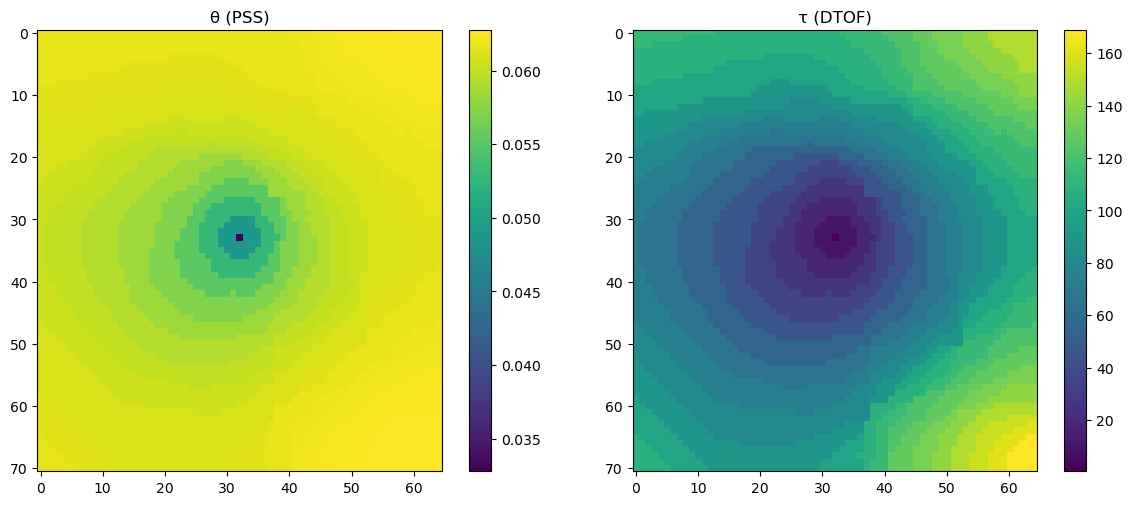

PSS интервалы: 27
tau_map shape: (71, 65)


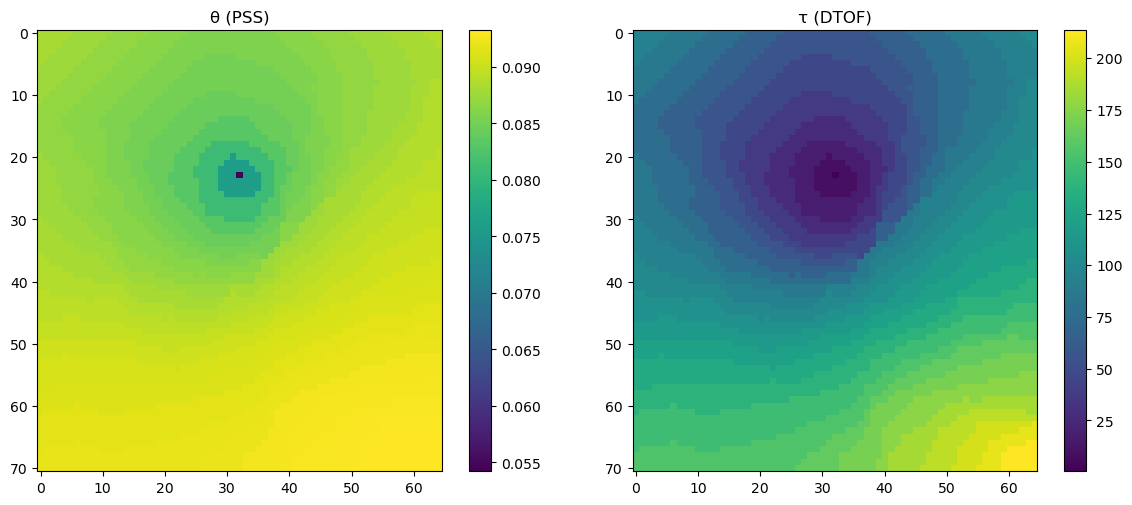

PSS интервалы: 31
tau_map shape: (71, 65)


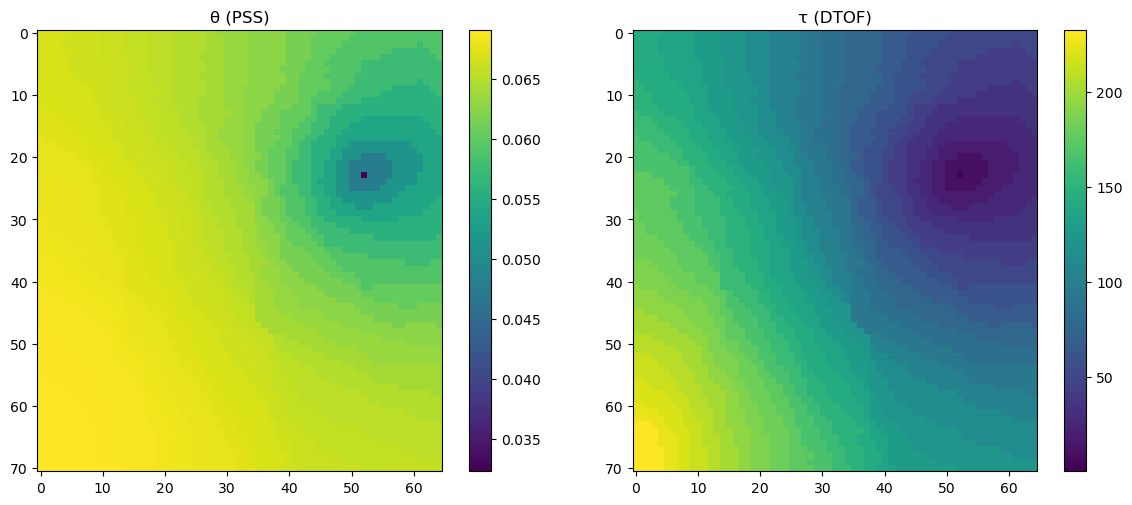

PSS интервалы: 31
tau_map shape: (71, 65)


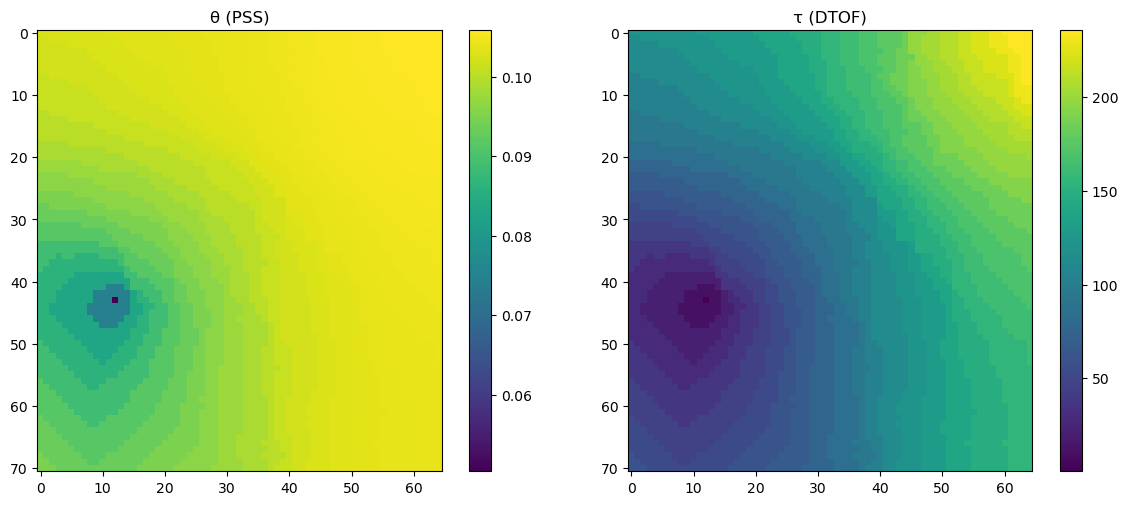

PSS интервалы: 33
tau_map shape: (71, 65)


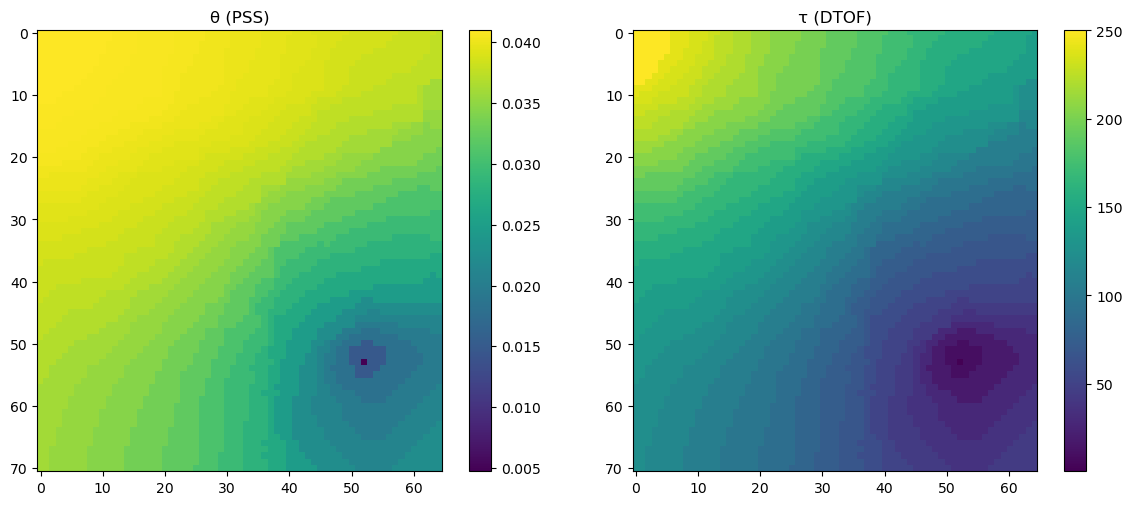

PSS интервалы: 30
tau_map shape: (71, 65)


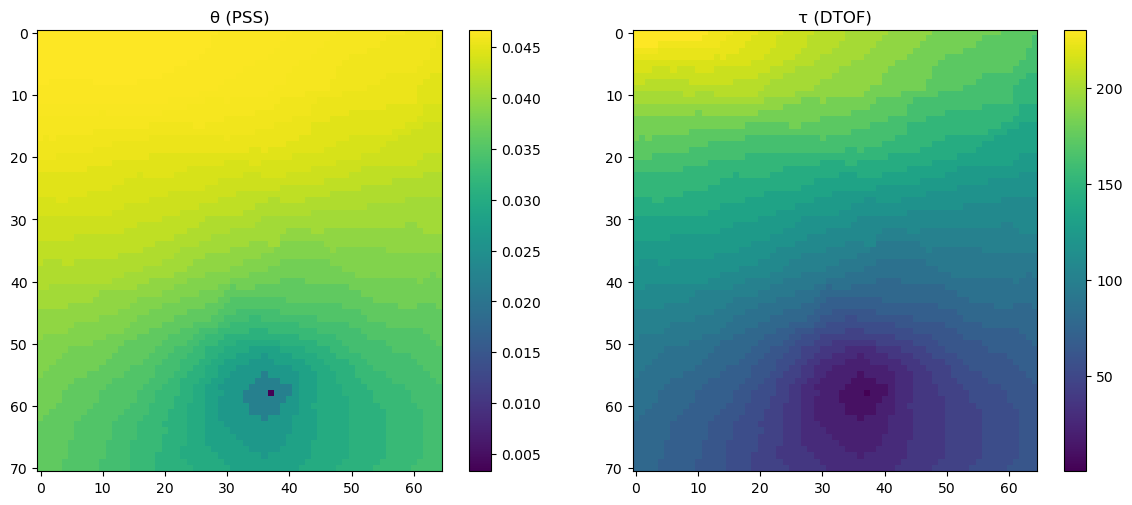

PSS интервалы: 30
tau_map shape: (71, 65)


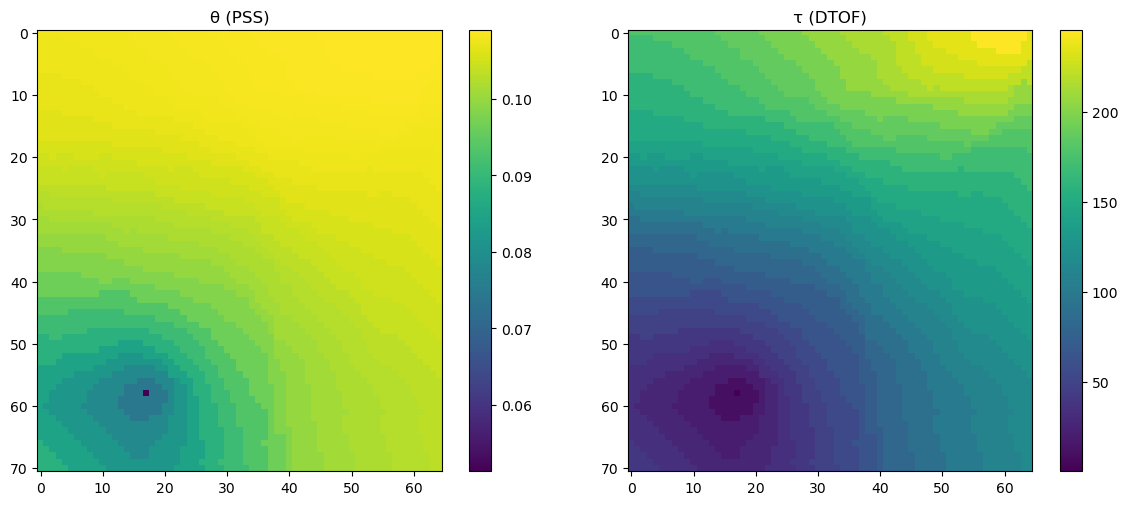

PSS интервалы: 32
tau_map shape: (71, 65)


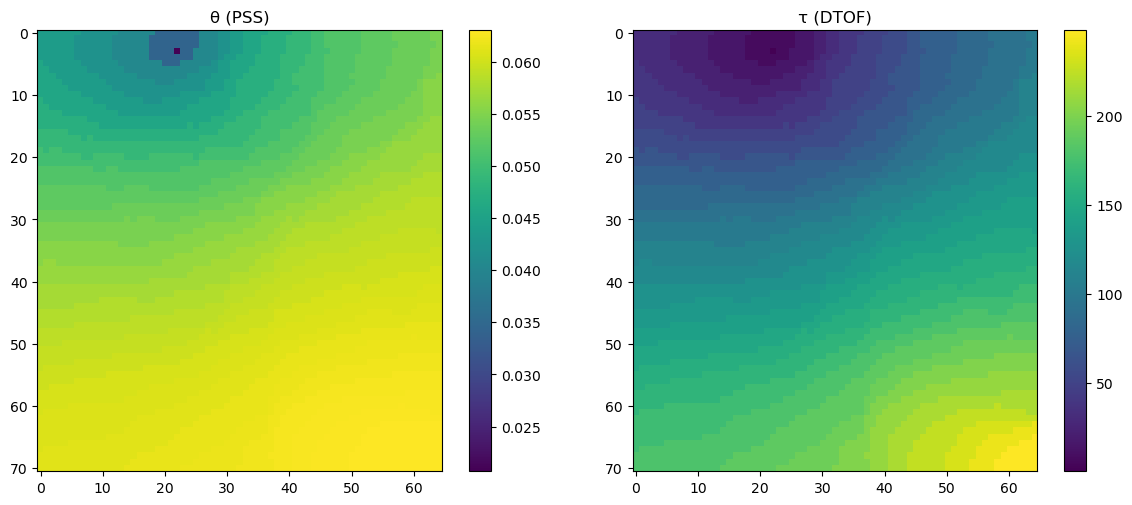

PSS интервалы: 33
tau_map shape: (71, 65)


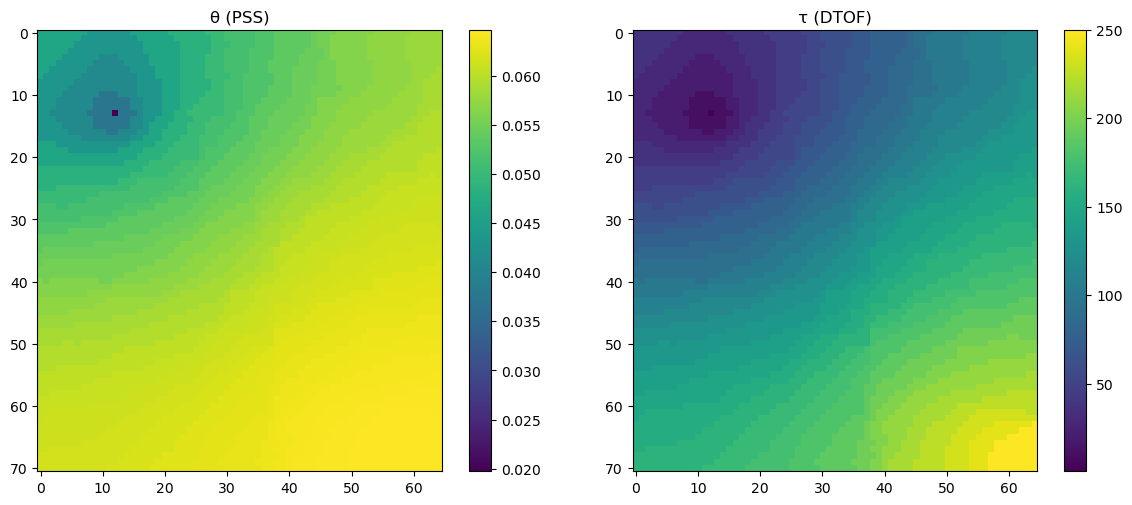

PSS интервалы: 29
tau_map shape: (71, 65)


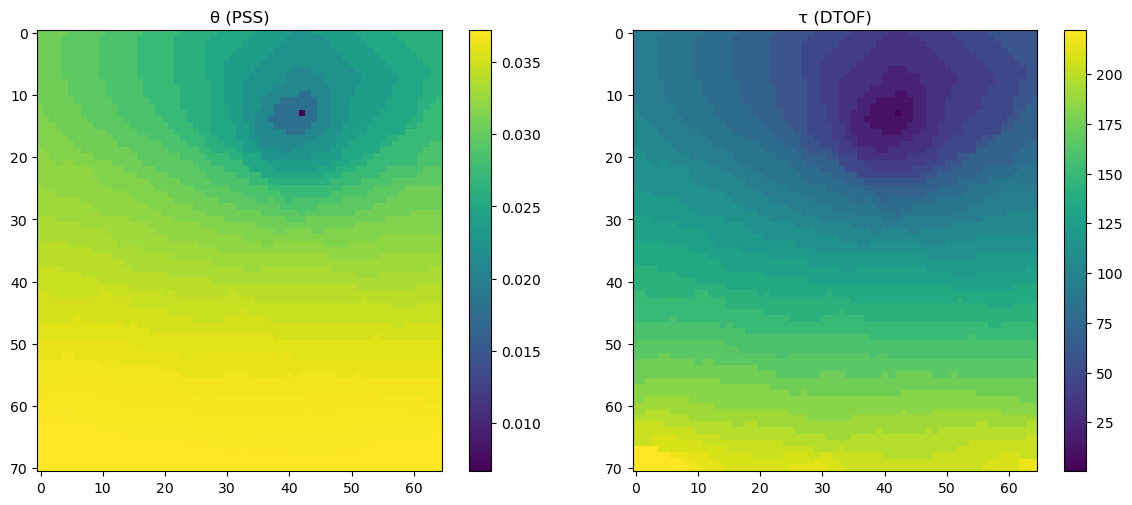

PSS интервалы: 30
tau_map shape: (71, 65)


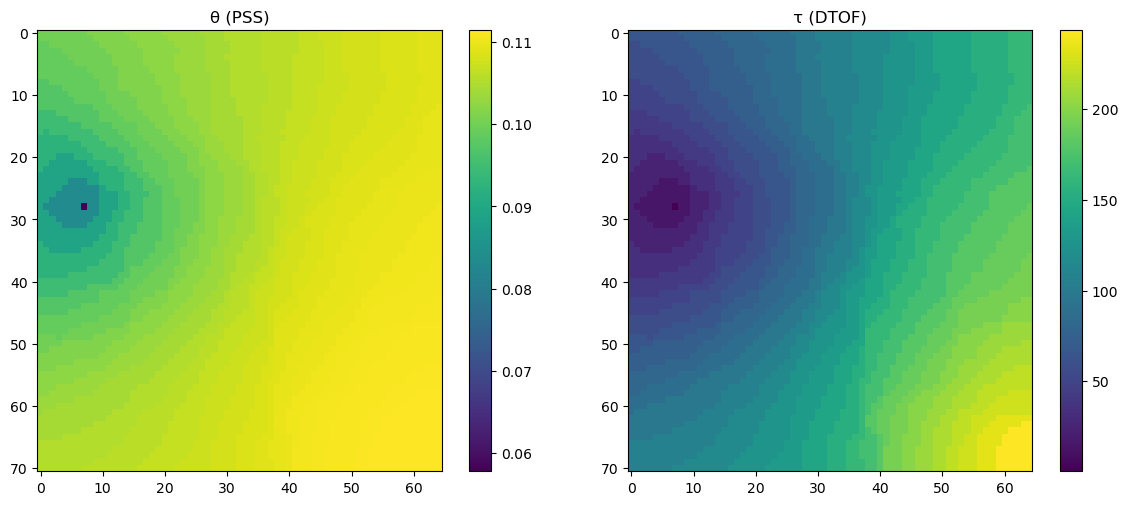

PSS интервалы: 29
tau_map shape: (71, 65)


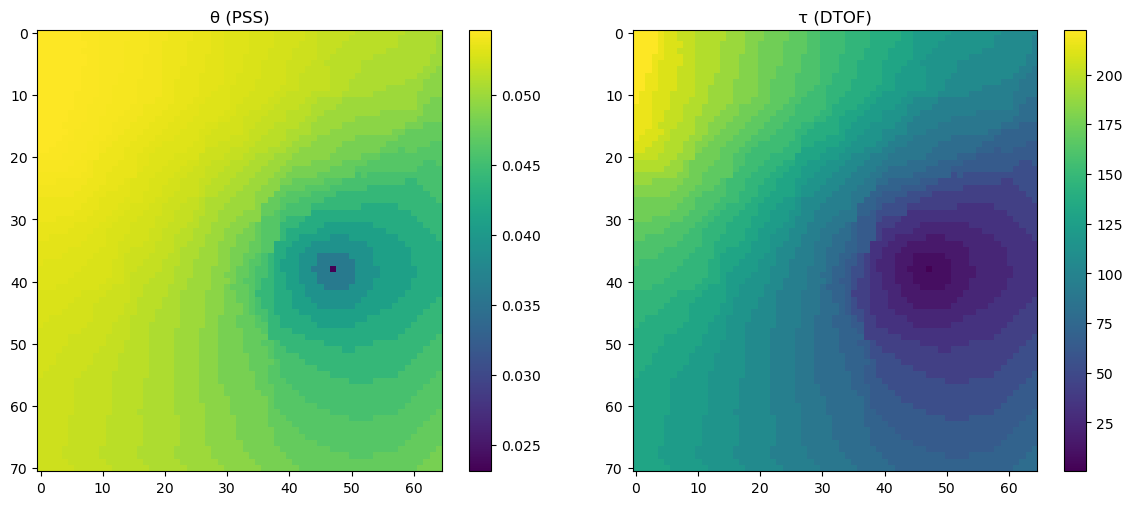

In [ ]:
tau_map_all = []
theta_int_all = []
tau_int_all = []
for i,well in enumerate(wells):
    tau_map, theta_int, tau_int = theta_to_tau_map(theta_discret_all[i], delta_Vp[i], ct, T_plus[i], T_minus[i], lam[0][0], tau_p_all[i])

    tau_map_all.append(tau_map)
    theta_int_all.append(theta_int)
    tau_int_all.append(tau_int)

    print(f"tau_map shape: {tau_map.shape}")
    plt.figure(figsize=(12, 5))
    plt.subplot(121); plt.imshow(theta_discret_all[i]); plt.colorbar(); plt.title('θ (PSS)')
    plt.subplot(122); plt.imshow(tau_map_all[i]); plt.colorbar(); plt.title('τ (DTOF)')
    plt.tight_layout()
    plt.show()

In [351]:
# time = 30
# v_time, q_D = volume_temporal(tau_map_1, Vp, time)

$J^{-1}(t)$ $-$ обратная продуктивность, которая меняется со временем и учитывает вовлекаемый в добычу объем пласта.

$J^{-1}(t)$ используется при построении матрицы суперпозиции.

$J^{-1}(t) =\dfrac{\bar{p}(t) - p_{wf}(t)}{q_t}$, но также $$J^{-1}(t) = \frac{1}{V_{p,max}} \int_{\tau_w}^{\tau_{max}} \frac{q_D(\tau,t)}{\lambda_{rt}(\tau,t) w_r(\tau)} dV_p(\tau) = \frac{1}{V_{p,max}} \int_{\tau_w}^{\tau_{max}} A(\tau,t) dV_p(\tau,t)$$

теперь посчитаем дискретно $A_n(t)$, используя посчитанный ранее безразмерный поток, который так же меняется со временем:

$A_n(t) = \mu \sum_{i=1}^n \left( \frac{q_D[i-1](t)}{T_i^-} + \frac{q_D[i](t)}{T_i^+} \right)$

и рекуррентная запись (при $A_0(t)=0$):

$A_k(t) = A_{k-1}(t) + \mu \left( \frac{q_D[k-1](t)}{T_k^-} + \frac{q_D[k](t)}{T_k^+} \right)$

In [352]:
def calculate_inverted_productivity(tau_map, time, T_minus, T_plus, mu, delta_Vp):
    # tau_map - карта j-той скважины!
    # well_i - координаты i-той скважины!
    A = np.zeros(len(T_minus))
    q_D = q_D_at_time(tau_map, delta_Vp, time)
    A[0] = 0
    for k in range(1, len(q_D)):
        A[k] = A[k-1] + mu * (q_D[k-1]/T_minus[k] + q_D[k]/T_plus[k])
    # delta_Vp = calc_delta_Vp(tau_map, Vp)
    PV_total = np.sum(delta_Vp)
    J_inv = np.sum(A * delta_Vp) / PV_total
    

    return A, J_inv

теперь осталось посчитать $$M_{i,j}^{n+1} = \int_{\tau' = \tau_{w,j}}^{\tau_j(\vec{x}_i)} \frac{q_{D,j}(\tau', t^{n+1})}{\lambda_{rt}(S(\tau',0)) w_{r,j}(\tau')} d \tau' - J_{t,j}^{-1}(t^{n+1})$$

$$ \int_{\tau_w}^{\tau_j(x_i)} \frac{q_D(\tau,t)}{\lambda_{rt}(\tau,t) w_r(\tau)} d \tau =  A_j(\tau_j(x_i),t)  $$

$j - $ скважина-источник, то есть скважина, чей дебит создаёт возмущение давления.

$i - $ скважина-наблюдатель, то есть точка, в которой мы хотим узнать давление.

$\tau_j(\vec{x}_i)$ - координата $i$-той скважины в $\tau$-карте $j$-той скважины

значит, $M_{i,j} = A_j(\tau_j(x_i),t) - J_{t,j}^{-1}(t)$

сейчас я ещё разберусь как считать всё кроме обратной продуктивности и всё будет хорошо)))

In [353]:
# Цикл по всем скважинам
well_places = 0
well_places = []
for w in wells:
    well_places.append(w["rc"])
print(well_places)

# теперь в well_places только индексы скважин. твой словарь не переписываю

[(33, 32), (23, 32), (23, 52), (43, 12), (53, 52), (58, 37), (58, 17), (3, 22), (13, 12), (13, 42), (28, 7), (38, 47)]


In [354]:
tau_maps = tau_map_all.copy() # карты все сложить в один список тоже удобно будет ... 

In [355]:
# i - target well: где смотрим номер интервала
# j - source well: чья tau-карта
def get_tau_j(i,j,well_places,tau_maps):
    tau_at_i_in_j = tau_maps[j][well_places[i]]
    tau_unique = np.sort(np.unique(tau_maps[j]))
    k = np.argmin(np.abs(tau_unique - tau_at_i_in_j))
    return k
# обозначила за новую букву чтобы не путать i,j потому что здесь это номера скважин.


теперь $k = \tau_j(\vec{x}_i)$ - координата $i$-той скважины в $\tau$-карте $j$-той скважины

то есть номер интервала $\tau$ карты от скважины $j$, в который попала скважина $i$

## Построение системы

и вот до этого номера интервала надо считать $A_j$ для $M_{i,j}$

$M_{i,j}(t)=A_j[k](t)-J_{t,j}^{-1}(t)$

здесь ничего не будет работать, пока не появится такой же список для $q_D$, $T^-$, $T^+$

то есть как мы сложили координаты скважин в wells, как мы сложили карты $\tau$ в tau_maps, так же нужно сложить q_D и T_minus, T_plus в свои списки и итерировать по номеру скважины ....

In [356]:
def calculate_M_i_j_at_time(i,j,well_places,tau_maps, time):
    tau_map = np.array(tau_maps[j])
    A, J =calculate_inverted_productivity(tau_map, time, T_minus[j], T_plus[j], mu, delta_Vp[j])
    k = get_tau_j(i,j,well_places,tau_maps)
    M = A[k] - J
    return M
# вот так должно сработать, если всё записать правильно...

In [357]:
M = np.zeros((len(well_places), len(well_places)))

In [358]:
def pv_average(field, Vp):
    field = np.asarray(field, dtype=float)
    Vp = np.asarray(Vp, dtype=float)
    return float(np.sum(field * Vp) / np.sum(Vp))


def tau_index_at_point(tau_map, rc):
    """
    Возвращает индекс PSS/DTOF-интервала в точке rc.

    tau_map может быть:
    1. индексной картой 0..N-1 или 1..N;
    2. картой float-значений tau.
    """
    tau_map = np.asarray(tau_map)
    value = tau_map[rc]

    unique_values = np.sort(np.unique(tau_map))

    # Если карта индексная и начинается с 0
    if np.issubdtype(tau_map.dtype, np.integer):
        idx = int(value)

        if unique_values.min() == 1:
            idx -= 1

        return idx

    # Если float-карта, ищем номер уникального tau-значения
    idx = int(np.argmin(np.abs(unique_values - value)))
    return idx


def calculate_A_J_for_well_at_time(
    tau_map_j,
    T_minus_j,
    T_plus_j,
    delta_Vp_j,
    mu,
    elapsed_time,
):
    """
    Считает A_j(k, t) и J_j^{-1}(t) для одной source-скважины j.

    A_j — накопленная функция сопротивления по PSS/DTOF-интервалам.
    J_inv — PV-взвешенное среднее A_j.
    """

    tau_map_j = np.asarray(tau_map_j)
    T_minus_j = np.asarray(T_minus_j, dtype=float)
    T_plus_j = np.asarray(T_plus_j, dtype=float)
    delta_Vp_j = np.asarray(delta_Vp_j, dtype=float)

    if elapsed_time <= 0:
        A = np.zeros_like(delta_Vp_j, dtype=float)
        J_inv = 0.0
        return A, J_inv

    q_D = np.asarray(
        q_D_at_time(tau_map_j, delta_Vp_j, elapsed_time),
        dtype=float,
    )

    n = len(q_D)

    if not (len(T_minus_j) == len(T_plus_j) == len(delta_Vp_j) == n):
        raise ValueError(
            "Несогласованные длины для source-скважины: "
            f"q_D={len(q_D)}, "
            f"T_minus={len(T_minus_j)}, "
            f"T_plus={len(T_plus_j)}, "
            f"delta_Vp={len(delta_Vp_j)}"
        )

    if np.any(~np.isfinite(T_minus_j)) or np.any(~np.isfinite(T_plus_j)):
        raise ValueError("T_minus/T_plus содержит NaN или inf")

    if np.any(T_minus_j <= 0) or np.any(T_plus_j <= 0):
        raise ValueError("T_minus/T_plus должны быть положительными")

    A = np.zeros(n, dtype=float)

    for k in range(1, n):
        A[k] = A[k - 1] + mu * (
            q_D[k - 1] / T_minus_j[k]
            + q_D[k] / T_plus_j[k]
        )

    J_inv = float(np.sum(A * delta_Vp_j) / np.sum(delta_Vp_j))

    return A, J_inv

In [359]:
ct

2.1311285583135532e-06

In [360]:
def build_M_eq39_at_time(
    wells,
    tau_map_all,
    T_minus,
    T_plus,
    delta_Vp,
    mu,
    time_n,
    well_start_times=None,
):
    """
    Строит M_ij(t_n) по формуле (39).

    M[i, j] = A_j(tau_j(x_i), t_n - t_start_j) - J_j^{-1}(t_n - t_start_j)

    i — target well;
    j — source well.
    """

    n_wells = len(wells)

    if well_start_times is None:
        well_start_times = np.zeros(n_wells, dtype=float)
    else:
        well_start_times = np.asarray(well_start_times, dtype=float)

    M_coeff = np.zeros((n_wells, n_wells), dtype=float)

    A_all = []
    J_inv_all = []

    for j in range(n_wells):
        elapsed_j = time_n - well_start_times[j]

        A_j, J_inv_j = calculate_A_J_for_well_at_time(
            tau_map_j=tau_map_all[j],
            T_minus_j=T_minus[j],
            T_plus_j=T_plus[j],
            delta_Vp_j=delta_Vp[j],
            mu=mu,
            elapsed_time=elapsed_j,
        )

        A_all.append(A_j)
        J_inv_all.append(J_inv_j)

    for i in range(n_wells):
        rc_i = wells[i]["rc"]

        for j in range(n_wells):
            elapsed_j = time_n - well_start_times[j]

            if elapsed_j <= 0:
                M_coeff[i, j] = 0.0
                continue

            k_ij = tau_index_at_point(tau_map_all[j], rc_i)
            M_coeff[i, j] = A_all[j][k_ij] - J_inv_all[j]

    return M_coeff, A_all, J_inv_all

In [361]:
def build_superposition_system_eq38(
    M_coeff,
    ct,
    V_res,
    dt,
    p_avg_prev,
    wells,
    controls,
    p_init_map=None,
    p_init_avg=None,
):
    """
    Неизвестные:
        x = [p_avg, pwf_1, ..., pwf_N, q_1, ..., q_N]

    controls[i]:
        {"mode": "rate", "value": q_target}
        или
        {"mode": "bhp", "value": bhp_target}
    """

    M_coeff = np.asarray(M_coeff, dtype=float)
    n = M_coeff.shape[0]

    if M_coeff.shape != (n, n):
        raise ValueError("M_coeff must be square")

    if len(wells) != n:
        raise ValueError("len(wells) != M_coeff.shape[0]")

    if len(controls) != n:
        raise ValueError("len(controls) != M_coeff.shape[0]")

    A_sys = np.zeros((2 * n + 1, 2 * n + 1), dtype=float)
    y_sys = np.zeros(2 * n + 1, dtype=float)

    # 1) Material balance:
    # ct * V * p_avg^n + dt * sum(q_i^n) = ct * V * p_avg^{n-1}
    A_sys[0, 0] = ct * V_res
    A_sys[0, 1 + n : 1 + 2 * n] = dt
    y_sys[0] = ct * V_res * p_avg_prev

    # 2) Well pressure equations:
    # p_avg - pwf_i + sum_j M_ij q_j = -hydro_offset_i
    for i, well in enumerate(wells):
        row = 1 + i

        A_sys[row, 0] = 1.0
        A_sys[row, 1 + i] = -1.0
        A_sys[row, 1 + n : 1 + 2 * n] = M_coeff[i, :]

        if p_init_map is not None:
            if p_init_avg is None:
                raise ValueError("p_init_avg must be provided with p_init_map")

            hydro_offset_i = float(p_init_map[well["rc"]] - p_init_avg)
        else:
            hydro_offset_i = 0.0

        y_sys[row] = -hydro_offset_i

    # 3) Well controls
    for i, ctrl in enumerate(controls):
        row = 1 + n + i

        if ctrl["mode"] == "rate":
            A_sys[row, 1 + n + i] = 1.0
            y_sys[row] = float(ctrl["value"])

        elif ctrl["mode"] == "bhp":
            A_sys[row, 1 + i] = 1.0
            y_sys[row] = float(ctrl["value"])

        else:
            raise ValueError(f"Unknown control mode: {ctrl['mode']}")

    return A_sys, y_sys

In [362]:
def solve_one_pss_step(
    time_n,
    dt_n,
    p_avg_prev,
    wells,
    tau_map_all,
    T_minus,
    T_plus,
    delta_Vp,
    mu,
    ct,
    V_res,
    q_targets,
    p_init_map,
    p_init_avg,
    bhp_min=None,
    well_start_times=None,
    previous_modes=None,
    max_switch_iter=20,
):
    """
    Один временной шаг PSS-DTOF.

    q_targets > 0 — добыча.
    bhp_min — нижнее BHP-ограничение для добывающих скважин.
    """
    n = len(wells)
    q_targets = np.asarray(q_targets, dtype=float)

    if well_start_times is None:
        well_start_times = np.zeros(n, dtype=float)
    else:
        well_start_times = np.asarray(well_start_times, dtype=float)

    M_coeff, A_all, J_inv_all = build_M_eq39_at_time(
        wells=wells,
        tau_map_all=tau_map_all,
        T_minus=T_minus,
        T_plus=T_plus,
        delta_Vp=delta_Vp,
        mu=mu,
        time_n=time_n,
        well_start_times=well_start_times,
    )
    M_cell = M_coeff.copy()

    M_wf = M_cell.copy()

    for i in range(n):
        if time_n < well_start_times[i]:
            continue

        WI_i = T_minus[i][0]
        M_wf[i, i] -= mu / WI_i
    controls = []

    for i in range(n):
        active_i = time_n >= well_start_times[i]

        if not active_i:
            controls.append({"mode": "rate", "value": 0.0})
            continue

        if previous_modes is not None and previous_modes[i] == "bhp" and bhp_min is not None:
            controls.append({"mode": "bhp", "value": float(bhp_min)})
        else:
            controls.append({"mode": "rate", "value": float(q_targets[i])})

    for switch_iter in range(max_switch_iter):
        A_sys, y_sys = build_superposition_system_eq38(
            M_coeff=M_wf,
            ct=ct,
            V_res=V_res,
            dt=dt_n,
            p_avg_prev=p_avg_prev,
            wells=wells,
            controls=controls,
            p_init_map=p_init_map,
            p_init_avg=p_init_avg,
        )

        x = np.linalg.solve(A_sys, y_sys)

        p_avg = x[0]
        pwf = x[1 : 1 + n]
        q_rates = x[1 + n : 1 + 2 * n]

        changed = False

        if bhp_min is not None:
            for i in range(n):
                active_i = time_n >= well_start_times[i]

                if not active_i:
                    continue

                if q_targets[i] <= 0:
                    continue

                if controls[i]["mode"] == "rate" and pwf[i] < bhp_min:
                    controls[i] = {"mode": "bhp", "value": float(bhp_min)}
                    changed = True

        if not changed:
            modes = [c["mode"] for c in controls]

            return {
                "time": time_n,
                "dt": dt_n,
                "M_cell": M_coeff,
                "M_wf": M_wf,
                "A_all": A_all,
                "J_inv_all": J_inv_all,
                "A_sys": A_sys,
                "y_sys": y_sys,
                "x": x,
                "p_avg": p_avg,
                "pwf": pwf,
                "q_rates": q_rates,
                "controls": controls,
                "modes": modes,
                "switch_iter": switch_iter,
            }

    raise RuntimeError("BHP switching did not converge")

In [363]:
wells

[{'name': 'W1', 'rc': (33, 32), 'WI': 9.533706339933905},
 {'name': 'W2', 'rc': (23, 32), 'WI': 5.763467404811833},
 {'name': 'W3', 'rc': (23, 52), 'WI': 9.674383628402838},
 {'name': 'W4', 'rc': (43, 12), 'WI': 6.203823794230032},
 {'name': 'W5', 'rc': (53, 52), 'WI': 65.99340548261343},
 {'name': 'W6', 'rc': (58, 37), 'WI': 94.15990111614882},
 {'name': 'W7', 'rc': (58, 17), 'WI': 6.088909776441213},
 {'name': 'W8', 'rc': (3, 22), 'WI': 15.08394627402298},
 {'name': 'W9', 'rc': (13, 12), 'WI': 15.83417763266491},
 {'name': 'W10', 'rc': (13, 42), 'WI': 46.91853383045455},
 {'name': 'W11', 'rc': (28, 7), 'WI': 5.40868914311614},
 {'name': 'W12', 'rc': (38, 47), 'WI': 13.50471720640984}]

In [364]:
def tau_index_map(tau_map, n_intervals):
    """
    Возвращает карту индексов 0..n_intervals-1.
    """
    tau_map = np.asarray(tau_map)

    if np.issubdtype(tau_map.dtype, np.integer):
        idx = tau_map.astype(int)

        if idx.min() == 1 and idx.max() == n_intervals:
            idx = idx - 1

        if idx.min() < 0 or idx.max() >= n_intervals:
            raise ValueError(
                f"Bad integer tau_map indices: min={idx.min()}, max={idx.max()}, n={n_intervals}"
            )

        return idx

    unique_values, inv = np.unique(tau_map, return_inverse=True)

    if len(unique_values) != n_intervals:
        rounded = np.rint(tau_map).astype(int)

        if np.allclose(tau_map, rounded, rtol=0, atol=1e-10):
            idx = rounded

            if idx.min() == 1 and idx.max() == n_intervals:
                idx = idx - 1

            if idx.min() >= 0 and idx.max() < n_intervals:
                return idx

        raise ValueError(
            f"tau_map has {len(unique_values)} unique values, "
            f"but expected {n_intervals} intervals"
        )

    return inv.reshape(tau_map.shape)


def reconstruct_pressure_map_at_step(
    step_result,
    wells,
    tau_map_all,
    p_init_map,
    p_init_avg,
    mu, 
    T_minus,
    well_start_times=None,
):
    n = len(wells)

    if well_start_times is None:
        well_start_times = np.zeros(n, dtype=float)
    else:
        well_start_times = np.asarray(well_start_times, dtype=float)

    time_n = step_result["time"]
    p_avg = step_result["p_avg"]
    q_rates = step_result["q_rates"]
    A_all = step_result["A_all"]
    J_inv_all = step_result["J_inv_all"]
    p_map = p_avg + (np.asarray(p_init_map, dtype=float) - p_init_avg)

    components = []

    for j in range(n):
        if time_n < well_start_times[j]:
            component = np.zeros_like(p_map, dtype=float)
            components.append(component)
            continue

        A_j = A_all[j]
        J_inv_j = J_inv_all[j]
        #A_map_j = A_j.copy()
        #A_map_j[0] = mu / T_minus[j][0]

        idx_map_j = tau_index_map(tau_map_all[j], len(A_j))

        response_j = A_j[idx_map_j] - J_inv_j
        component = q_rates[j] * response_j

        p_map += component
        components.append(component)

    return p_map, components

## Финальные вычисления

In [365]:
P_init_map = p_init_map

In [366]:
available_tnav_months = np.array([month for month in reference_months if month > 0], dtype=int)
times = available_tnav_months * 30.5  # days

PInit_avg = pv_average(P_init_map, Vp)

print("PInit_avg:", PInit_avg)
print("P_init_map min/max:", P_init_map.min(), P_init_map.max())
print("available_tnav_months:", available_tnav_months.tolist())

n_wells = len(wells)
well_start_times = np.zeros(n_wells, dtype=float)

qw_surface = float(qw)
q_targets_surface = np.full(n_wells, qw_surface, dtype=float)
q_targets = np.full(n_wells, Bo * qw_surface, dtype=float)

print("single well surface rate:", qw_surface)
print("single well reservoir rate:", Bo * qw_surface)
print("total surface rate:", np.sum(q_targets_surface))
print("total reservoir rate:", np.sum(q_targets))

bhp_min = 170

PInit_avg: 217.74998962414205
P_init_map min/max: 212.65586853027344 225.8707427978516
available_tnav_months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 20

In [367]:
pss_results = []

p_avg_prev = PInit_avg
previous_modes = None

for step_id, time_n in enumerate(times):
    current_month = int(available_tnav_months[step_id])

    if step_id == 0:
        dt_n = time_n
    else:
        dt_n = time_n - times[step_id - 1]

    step_result = solve_one_pss_step(
        time_n=time_n,
        dt_n=dt_n,
        p_avg_prev=p_avg_prev,
        wells=wells,
        tau_map_all=tau_map_all,
        T_minus=T_minus,
        T_plus=T_plus,
        delta_Vp=delta_Vp,
        mu=mu,
        ct=ct,
        V_res=V_res,
        q_targets=q_targets,
        p_init_map=P_init_map,
        p_init_avg=PInit_avg,
        bhp_min=bhp_min,
        well_start_times=well_start_times,
        previous_modes=previous_modes,
    )

    p_map, pressure_components = reconstruct_pressure_map_at_step(
        step_result=step_result,
        wells=wells,
        tau_map_all=tau_map_all,
        p_init_map=P_init_map,
        p_init_avg=PInit_avg,
        mu = mu,
        T_minus = T_minus,
        well_start_times=well_start_times,
    )

    step_result["month"] = current_month
    step_result["p_map"] = p_map
    step_result["pressure_components"] = pressure_components

    pss_results.append(step_result)

    p_avg_prev = step_result["p_avg"]
    previous_modes = step_result["modes"]

    print(
        f"step={step_id+1:03d}, "
        f"month={current_month}, "
        f"time={time_n:.1f} d, "
        f"dt={dt_n:.1f} d, "
        f"p_avg={step_result['p_avg']:.3f}, "
        f"sum_q_res={np.sum(step_result['q_rates']):.3f}, "
        f"min_pwf={np.min(step_result['pwf']):.3f}, "
        f"modes={step_result['modes'].count('rate')} rate / "
        f"{step_result['modes'].count('bhp')} bhp"
    )


step=001, month=1, time=30.5 d, dt=30.5 d, p_avg=217.590, sum_q_res=4500.000, min_pwf=183.397, modes=12 rate / 0 bhp
step=002, month=2, time=61.0 d, dt=30.5 d, p_avg=217.431, sum_q_res=4500.000, min_pwf=182.920, modes=12 rate / 0 bhp
step=003, month=3, time=91.5 d, dt=30.5 d, p_avg=217.271, sum_q_res=4500.000, min_pwf=182.541, modes=12 rate / 0 bhp
step=004, month=4, time=122.0 d, dt=30.5 d, p_avg=217.112, sum_q_res=4500.000, min_pwf=182.233, modes=12 rate / 0 bhp
step=005, month=5, time=152.5 d, dt=30.5 d, p_avg=216.952, sum_q_res=4500.000, min_pwf=181.971, modes=12 rate / 0 bhp
step=006, month=6, time=183.0 d, dt=30.5 d, p_avg=216.793, sum_q_res=4500.000, min_pwf=181.736, modes=12 rate / 0 bhp
step=007, month=7, time=213.5 d, dt=30.5 d, p_avg=216.633, sum_q_res=4500.000, min_pwf=181.518, modes=12 rate / 0 bhp
step=008, month=8, time=244.0 d, dt=30.5 d, p_avg=216.473, sum_q_res=4500.000, min_pwf=181.309, modes=12 rate / 0 bhp
step=009, month=9, time=274.5 d, dt=30.5 d, p_avg=216.314, 

In [368]:
last = pss_results[-1]

p_x = last["p_map"]
M_cell_last = last["M_cell"]
M_wf_last = last["M_wf"]
p_avg = last["p_avg"]
pwf = last["pwf"]
q_rates = last["q_rates"]

print("month:", last["month"])
print("time:", last["time"])
print("p_avg:", p_avg)
print("p_x min/max:", p_x.min(), p_x.max())
print("q_rates_res:", q_rates)
print("pwf:", pwf)


month: 300
time: 9150.0
p_avg: 177.21710426990657
p_x min/max: 170.61003351043638 187.140453026355
q_rates_res: [110.66626485  78.72391016 231.70585557  77.8429955  308.76246837
 183.81022406  88.40946244 165.60588104 121.7152423  375.
  72.90932831 194.09413637]
pwf: [170.         170.         170.         170.         170.
 170.         170.         170.         170.         171.58874106
 170.         170.        ]


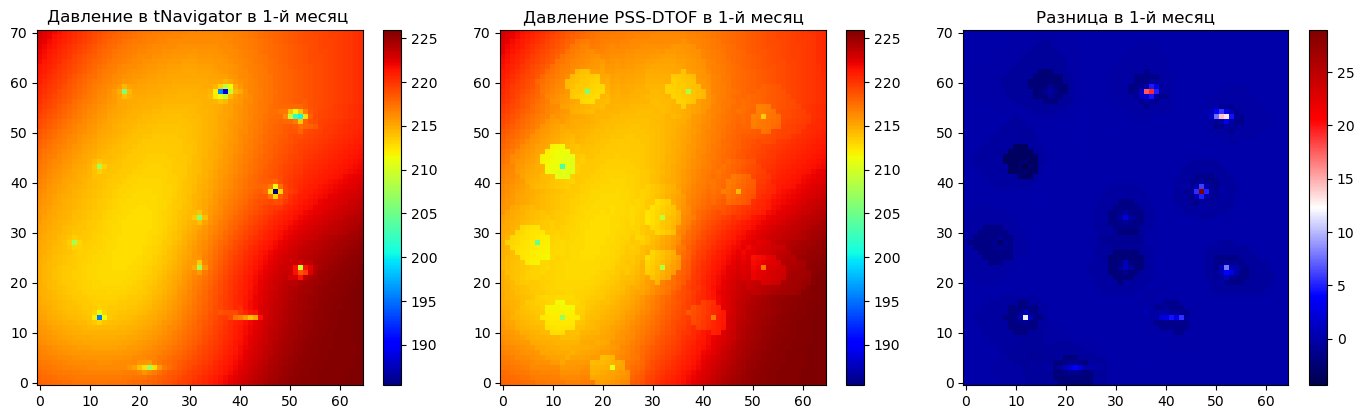

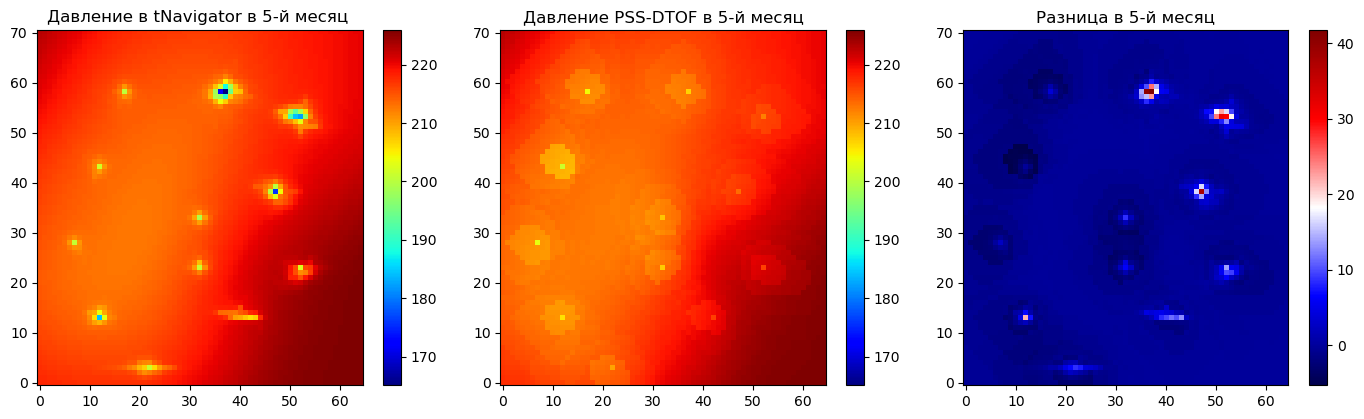

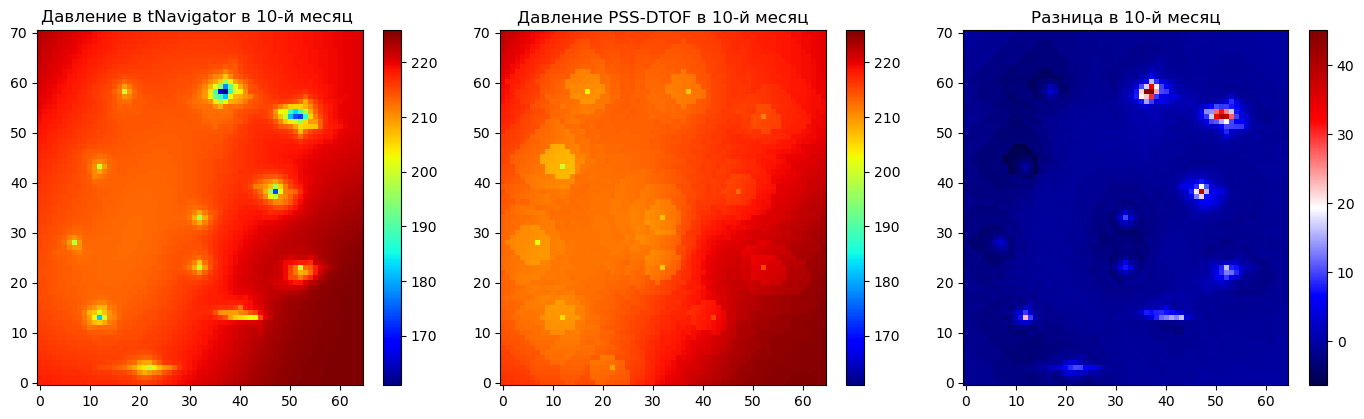

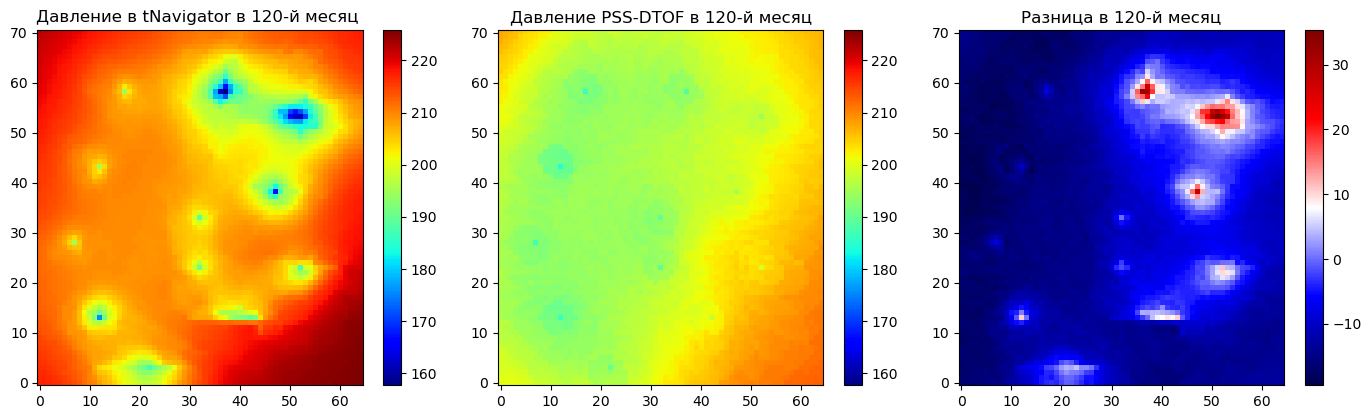

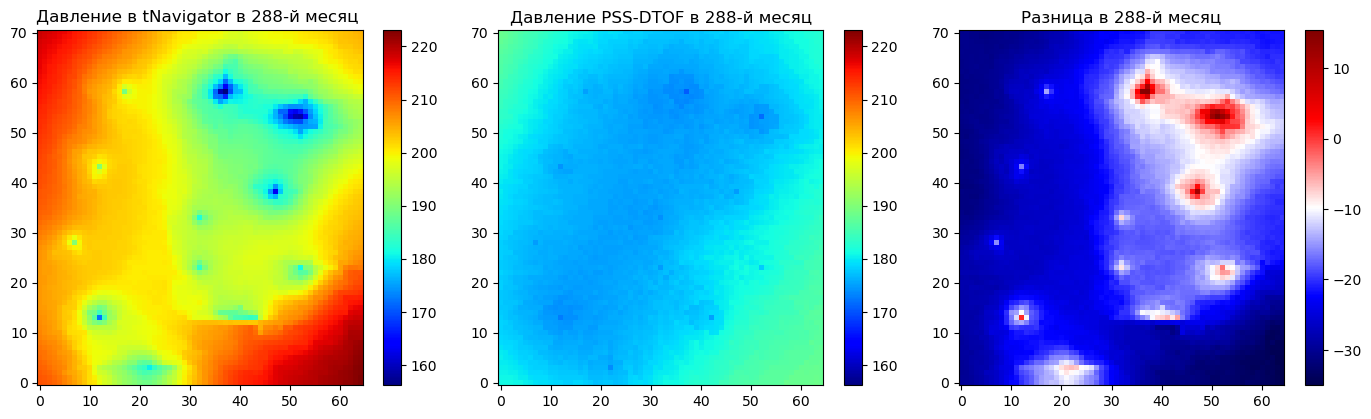

In [369]:
import numpy as np

key_months = [1, 5, 10, 120, 288]

for month in key_months:
    ref = tnav_by_month[month]
    pss = pss_results[reference_months.index(month)]["p_map"]
    diff = pss - ref

    # Общая шкала для первых двух графиков
    vmin = min(np.nanmin(ref), np.nanmin(pss))
    vmax = max(np.nanmax(ref), np.nanmax(pss))

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    im1 = plt.imshow(ref, cmap='jet', origin='lower', vmin=vmin, vmax=vmax)
    plt.colorbar(im1)
    plt.title(f"Давление в tNavigator в {month}-й месяц ")

    plt.subplot(1, 3, 2)
    im2 = plt.imshow(pss, cmap='jet', origin='lower', vmin=vmin, vmax=vmax)
    plt.colorbar(im2)
    plt.title(f"Давление PSS-DTOF в {month}-й месяц")

    plt.subplot(1, 3, 3)
    im3 = plt.imshow(diff, cmap='seismic', origin='lower')
    plt.colorbar(im3)
    plt.title(f"Разница в {month}-й месяц")

    plt.tight_layout()
    plt.show()

Предупреждение: Для месяца 300 нет результата PSS
=== Ошибки сравнения PSS-DTOF vs tNavigator ===
     month      MAE     RMSE  Max_Error     Bias  Relative_Error_%  Mean_TNav  \
0        0   0.2078   0.5752    10.0363  -0.1462            0.0954   217.8685   
1        1   0.3359   0.9576    28.9120  -0.2026            0.1543   217.7588   
2        2   0.4836   1.3149    34.0287  -0.2775            0.2222   217.6671   
3        3   0.6436   1.6254    36.0455  -0.3451            0.2958   217.5686   
4        4   0.8067   1.8871    38.2335  -0.4173            0.3709   217.4748   
..     ...      ...      ...        ...      ...               ...        ...   
295    295  21.6205  22.7983    35.6190 -21.5317           10.8380   199.4871   
296    296  21.6430  22.8249    35.6985 -21.5544           10.8520   199.4369   
297    297  21.6665  22.8523    35.7781 -21.5781           10.8665   199.3883   
298    298  21.6879  22.8778    35.8556 -21.5997           10.8800   199.3382   
299    299 

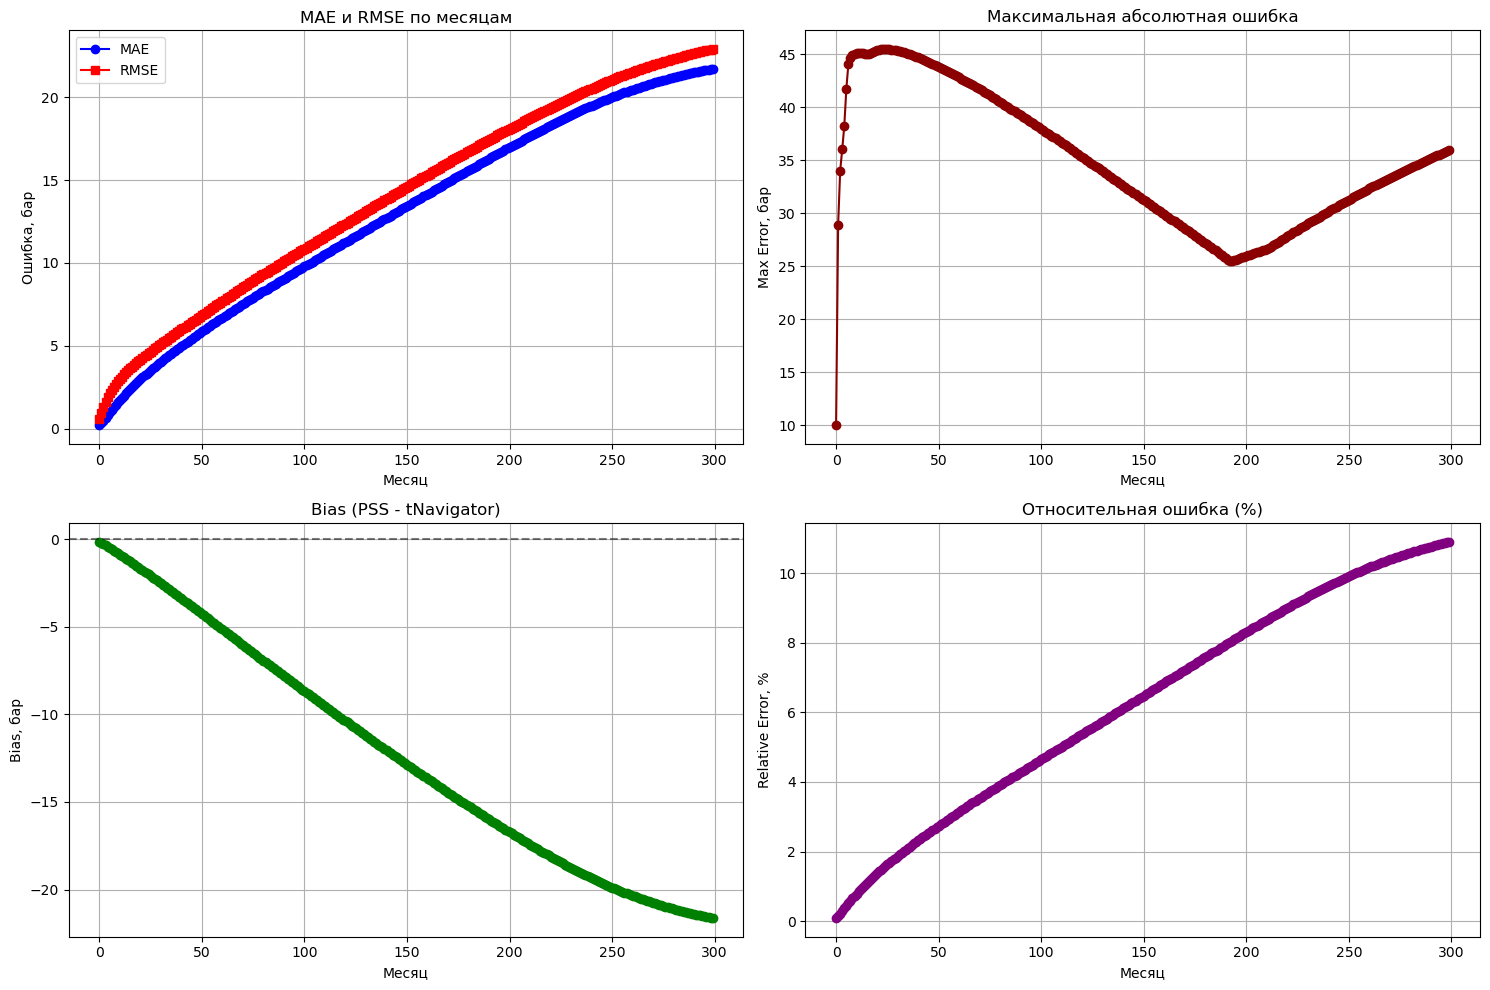

,MAE,RMSE,Max_Error,Bias,Relative_Error_%,Mean_TNav,Mean_PSS,Cells
month,,,,,,,,
0,0.207800,0.575200,10.036300,-0.146200,0.095400,217.868500,217.722300,4615
1,0.335900,0.957600,28.912000,-0.202600,0.154300,217.758800,217.556200,4615
2,0.483600,1.314900,34.028700,-0.277500,0.222200,217.667100,217.389600,4615
3,0.643600,1.625400,36.045500,-0.345100,0.295800,217.568600,217.223500,4615
4,0.806700,1.887100,38.233500,-0.417300,0.370900,217.474800,217.057500,4615
5,0.969000,2.126200,41.718000,-0.487400,0.445800,217.379200,216.891800,4615
6,1.127200,2.335600,44.083800,-0.561700,0.518800,217.287800,216.726200,4615
7,1.280000,2.519000,44.651400,-0.634800,0.589300,217.195600,216.560800,4615
8,1.428800,2.686400,44.902000,-0.709200,0.658100,217.104800,216.395600,4615


In [370]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Список для сбора ошибок
error_data = []

# Проходим по всем месяцам в tnav_by_month
for month in sorted(tnav_by_month.keys()):
    
    tnav_map = tnav_by_month[month]
    
    # Соответствие с pss_results:
    # tnav: 0..300
    # pss:  0..299  → для месяца 300 PSS результата нет
    if month < len(pss_results):          # т.е. month <= 299
        pss_map = pss_results[month]["p_map"]
        has_pss = True
    else:
        print(f"Предупреждение: Для месяца {month} нет результата PSS")
        has_pss = False
        continue  # пропускаем месяц 300 для расчёта ошибок
    
    # === Расчёт метрик ошибок ===
    diff = pss_map - tnav_map
    
    mae = np.mean(np.abs(diff))
    mse = np.mean(diff**2)
    rmse = np.sqrt(mse)
    max_error = np.max(np.abs(diff))
    bias = np.mean(diff)
    mean_tnav = np.mean(tnav_map)
    rel_error = mae / (mean_tnav + 1e-8)
    
    error_data.append({
        'month': month,
        'MAE': mae,
        'RMSE': rmse,
        'Max_Error': max_error,
        'Bias': bias,
        'Relative_Error_%': rel_error * 100,
        'Mean_TNav': mean_tnav,
        'Mean_PSS': np.mean(pss_map),
        'Cells': tnav_map.size
    })

# === Создание DataFrame ===
error_df = pd.DataFrame(error_data)

print("=== Ошибки сравнения PSS-DTOF vs tNavigator ===")
print(error_df.round(4))

# === Графики ошибок ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

x = error_df['month']

axes[0,0].plot(x, error_df['MAE'], 'o-', label='MAE', color='blue')
axes[0,0].plot(x, error_df['RMSE'], 's-', label='RMSE', color='red')
axes[0,0].set_title('MAE и RMSE по месяцам')
axes[0,0].set_xlabel('Месяц')
axes[0,0].set_ylabel('Ошибка, бар')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(x, error_df['Max_Error'], 'o-', color='darkred')
axes[0,1].set_title('Максимальная абсолютная ошибка')
axes[0,1].set_xlabel('Месяц')
axes[0,1].set_ylabel('Max Error, бар')
axes[0,1].grid(True)

axes[1,0].plot(x, error_df['Bias'], 'o-', color='green')
axes[1,0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1,0].set_title('Bias (PSS - tNavigator)')
axes[1,0].set_xlabel('Месяц')
axes[1,0].set_ylabel('Bias, бар')
axes[1,0].grid(True)

axes[1,1].plot(x, error_df['Relative_Error_%'], 'o-', color='purple')
axes[1,1].set_title('Относительная ошибка (%)')
axes[1,1].set_xlabel('Месяц')
axes[1,1].set_ylabel('Relative Error, %')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Красивая таблица
display(error_df.set_index('month').round(4).style
        .background_gradient(subset=['MAE', 'RMSE', 'Max_Error'], cmap='Reds')
        .background_gradient(subset=['Bias'], cmap='RdBu'))

In [371]:
import pandas as pd
import numpy as np

# Список для сбора ошибок
error_data = []

# Проходим по всем месяцам в tnav_by_month
for month in sorted(tnav_by_month.keys()):
    
    tnav_map = tnav_by_month[month]
    
    # Соответствие с pss_results:
    # tnav: 0..300
    # pss:  0..299  → для месяца 300 PSS результата нет
    if month < len(pss_results):          # т.е. month <= 299
        pss_map = pss_results[month]["p_map"]
        has_pss = True
    else:
        print(f"Предупреждение: Для месяца {month} нет результата PSS")
        has_pss = False
        continue  # пропускаем месяц 300 для расчёта ошибок
    
    # === Расчёт метрик ошибок ===
    diff = pss_map - tnav_map
    
    mae = np.mean(np.abs(diff))
    max_error = np.max(np.abs(diff))
    mean_tnav = np.mean(tnav_map)
    mean_pss = np.mean(pss_map)
    
    error_data.append({
        'month': month + 1,  # +1 чтобы месяцы были с 1, а не с 0
        'MAE': mae,
        'Max_Error': max_error,
        'Mean_TNav': mean_tnav,
        'Mean_PSS': mean_pss
    })

# === Создание DataFrame только с нужными столбцами ===
error_df = pd.DataFrame(error_data)

# Переименовываем столбцы для красоты
error_df.columns = ['Месяц', 'MAE', 'Макс_Ошибка', 'Среднее_TNav', 'Среднее_PSS']

# Округляем значения до 4 знаков
error_df = error_df.round(4)

# === ВЫВОД ТАБЛИЦЫ ДЛЯ ВСТАВКИ В WORD ===

# 1. Вывод в консоль (можно скопировать и вставить в Word)
print("\n" + "="*100)
print("ТАБЛИЦА ДЛЯ ВСТАВКИ В WORD")
print("="*100)
print(error_df.to_string(index=False))
print("="*100)

# 2. Сохранение в Excel (удобно копировать таблицу в Word)
error_df.to_excel('таблица_для_word.xlsx', index=False)
print("\n✓ Таблица сохранена в 'таблица_для_word.xlsx'")
print("  Откройте файл, скопируйте таблицу и вставьте в Word")

# 3. Сохранение в CSV
error_df.to_csv('таблица_для_word.csv', index=False, encoding='utf-8-sig')
print("✓ Таблица сохранена в 'таблица_для_word.csv'")

# 4. Копирование в буфер обмена (если установлен pyperclip)
try:
    import pyperclip
    # Форматируем как таблицу с табуляцией для Word
    clipboard_text = error_df.to_csv(sep='\t', index=False)
    pyperclip.copy(clipboard_text)
    print("✓ Таблица скопирована в буфер обмена!")
    print("  Перейдите в Word и нажмите Ctrl+V для вставки")
except ImportError:
    print("\n  Для копирования в буфер обмена установите:")
    print("  pip install pyperclip")

Предупреждение: Для месяца 300 нет результата PSS

ТАБЛИЦА ДЛЯ ВСТАВКИ В WORD
 Месяц     MAE  Макс_Ошибка  Среднее_TNav  Среднее_PSS
     1  0.2078      10.0363      217.8685     217.7223
     2  0.3359      28.9120      217.7588     217.5562
     3  0.4836      34.0287      217.6671     217.3896
     4  0.6436      36.0455      217.5686     217.2235
     5  0.8067      38.2335      217.4748     217.0575
     6  0.9690      41.7180      217.3792     216.8918
     7  1.1272      44.0838      217.2878     216.7262
     8  1.2800      44.6514      217.1956     216.5608
     9  1.4288      44.9020      217.1048     216.3956
    10  1.5742      45.0316      217.0179     216.2306
    11  1.7169      45.1068      216.9291     216.0658
    12  1.8559      45.1341      216.8438     215.9012
    13  1.9919      45.1358      216.7563     215.7368
    14  2.1251      45.1133      216.6694     215.5726
    15  2.2553      45.0620      216.5919     215.4086
    16  2.3820      45.0415      216.5070 

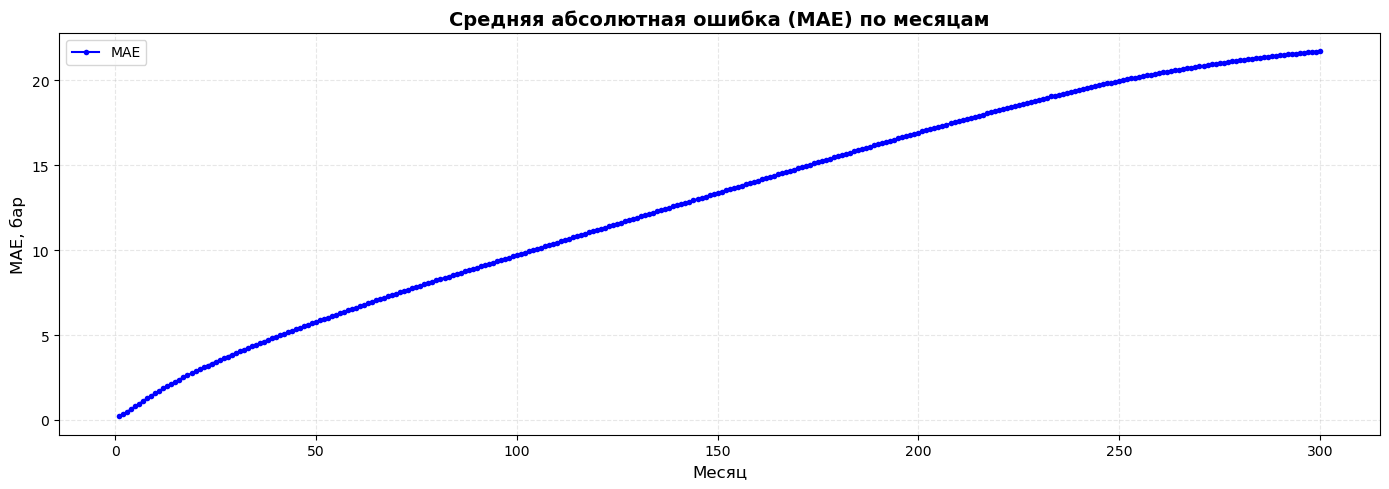

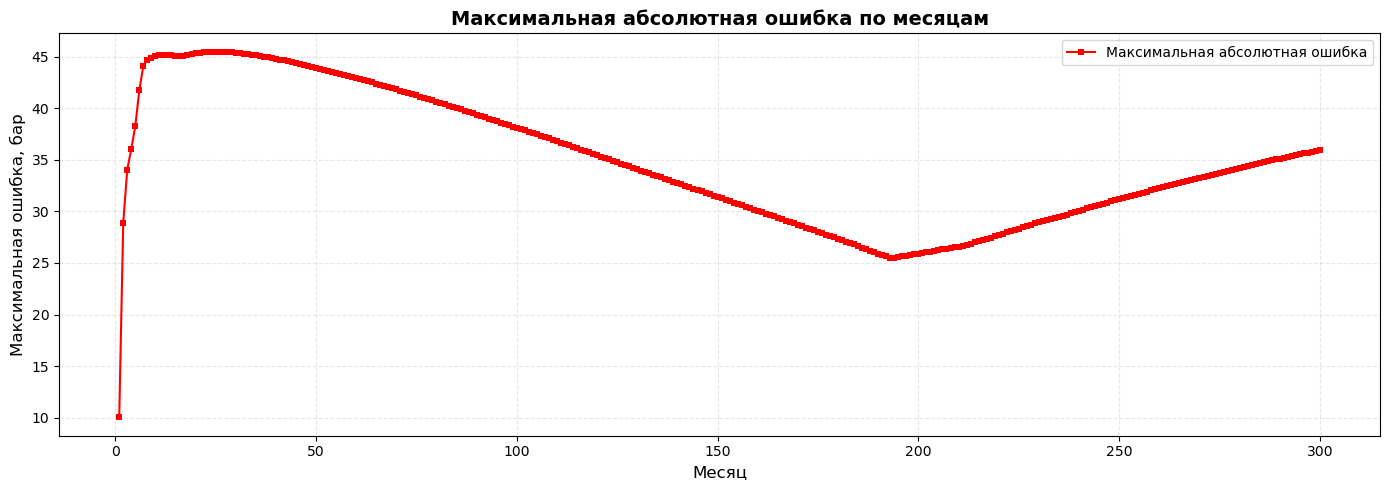

In [372]:
import matplotlib.pyplot as plt
import numpy as np

# Предполагается, что error_df уже создан и содержит столбцы:
# 'Месяц', 'MAE', 'Макс_Ошибка'

# Получаем данные
months = error_df['Месяц']
mae_values = error_df['MAE']
max_error_values = error_df['Макс_Ошибка']

# === ГРАФИК 1: MAE ===
plt.figure(figsize=(14, 5))
plt.plot(months, mae_values, 'o-', label='MAE', color='blue', linewidth=1.5, markersize=4, markerfacecolor='blue', markeredgewidth=0.01)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('MAE, бар', fontsize=12)
plt.title('Средняя абсолютная ошибка (MAE) по месяцам', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# === ГРАФИК 2: Максимальная абсолютная ошибка ===
plt.figure(figsize=(14, 5))
plt.plot(months, max_error_values, 's-', label='Максимальная абсолютная ошибка', color='red', linewidth=1.5, markersize=4, markerfacecolor='red', markeredgewidth=0.01)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Максимальная ошибка, бар', fontsize=12)
plt.title('Максимальная абсолютная ошибка по месяцам', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

=== Ошибки в скважинах (первые 10 строк) ===
   month well   p_tnav    p_pss   error  abs_error  rel_error_%
0      0   W1  215.083  209.508  -5.575      5.575        2.592
1      0   W2  216.637  209.026  -7.610      7.610        3.513
2      0   W3  223.957  217.884  -6.073      6.073        2.712
3      0   W4  214.324  204.288 -10.036     10.036        4.683
4      0   W5  218.599  214.006  -4.592      4.592        2.101
5      0   W6  215.356  208.922  -6.434      6.434        2.988
6      0   W7  215.536  206.511  -9.025      9.025        4.187
7      0   W8  217.114  211.632  -5.483      5.483        2.525
8      0   W9  213.887  207.558  -6.328      6.328        2.959
9      0  W10  221.897  217.404  -4.493      4.493        2.025


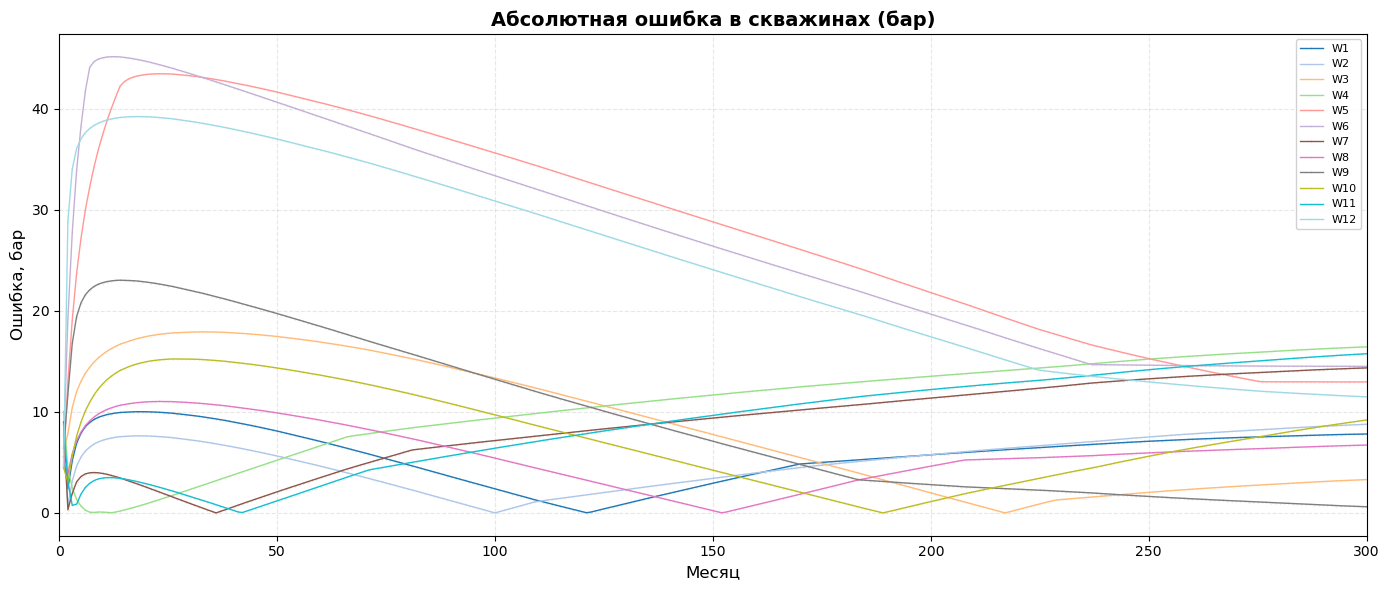

In [373]:
# ====================== АНАЛИЗ ОШИБОК В СКВАЖИНАХ ======================
well_error_data = []

for month in sorted(tnav_by_month.keys()):
    if month >= len(pss_results):
        continue  # пропускаем месяц 300
    
    tnav_map = tnav_by_month[month]
    pss_map = pss_results[month]["p_map"]
    
    for well in wells:
        r, c = well['rc']
        
        p_tnav = tnav_map[r, c]
        p_pss = pss_map[r, c]
        error = p_pss - p_tnav
        abs_error = abs(error)
        
        well_error_data.append({
            'month': month,
            'well': well['name'],
            'p_tnav': p_tnav,
            'p_pss': p_pss,
            'error': error,
            'abs_error': abs_error,
            'rel_error_%': abs_error / (p_tnav + 1e-8) * 100
        })

# Создаём DataFrame
well_df = pd.DataFrame(well_error_data)

print("=== Ошибки в скважинах (первые 10 строк) ===")
print(well_df.head(10).round(3))

# ====================== ГРАФИК АБСОЛЮТНОЙ ОШИБКИ ======================
plt.figure(figsize=(14, 6))

# Получаем список уникальных скважин
wells_list = well_df['well'].unique()

# Создаём цветовую карту с разными цветами для каждой скважины
colors = plt.cm.tab20(np.linspace(0, 1, len(wells_list)))

# Абсолютная ошибка по всем скважинам с разными цветами
for well_name, color in zip(wells_list, colors):
    data = well_df[well_df['well'] == well_name]
    plt.plot(data['month'] + 1, data['abs_error'], label=well_name, marker='o', markersize=0.1, linewidth=1, color=color)

plt.title('Абсолютная ошибка в скважинах (бар)', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.xlim(0,300)
plt.ylabel('Ошибка, бар', fontsize=12)

# Легенда внутри графика
plt.legend(loc='best', fontsize=8, framealpha=0.9)

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Playground

In [101]:
perm_1 = datareader_2('data/actual/case_1/permx_integral_1')
poro_1 = datareader_2('data/actual/case_1/poro_integral_1')

perm_2 = datareader_2('data/actual/case_2/permx_integral_2')
poro_2 = datareader_2('data/actual/case_2/poro_integral_2')

perm_3 = datareader_2('data/actual/case_3/permx_integral_3')
poro_3 = datareader_2('data/actual/case_3/poro_integral_3')

perm_4 = datareader_2('data/actual/case_4/permx_integral_4')
poro_4 = datareader_2('data/actual/case_4/poro_integral_4')

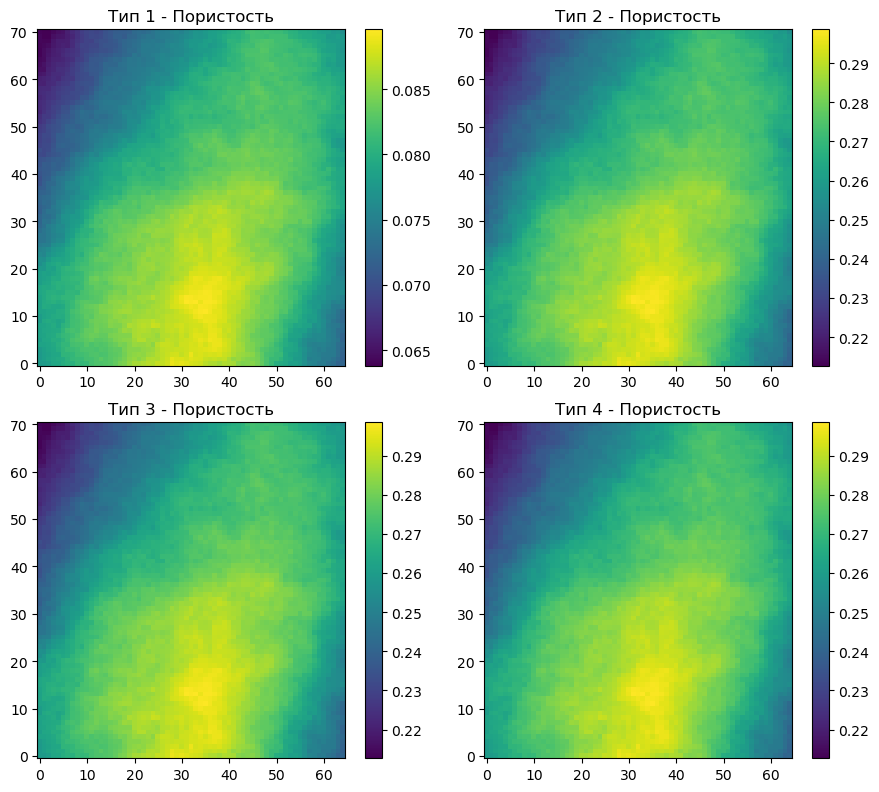

In [108]:
plt.figure(figsize=(9,8))

plt.subplot(2,2,1)
plt.imshow(poro_1, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Тип 1 - Пористость')

plt.subplot(2,2,2)
plt.imshow(poro_2, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Тип 2 - Пористость')

plt.subplot(2,2,3)
plt.imshow(poro_3, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Тип 3 - Пористость')

plt.subplot(2,2,4)
plt.imshow(poro_4, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Тип 4 - Пористость')

plt.tight_layout()
plt.show()